# Tabular-Only XGBoost - Mixed-All Multimodal Dataset

XGBoost on transaction features only from the multimodal mixed-all dataset.


**Part A** - Raw features 

**Part B** - Engineered features 

Threshold selection: **minimum expected cost** (FN × $50,000 + FP × $500).


In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from tabular_xgboost_utils import (
    build_preprocessor, compute_scale_pos_weight,
    build_xgb_pipeline, fit_model,
    evaluate_model, search_thresholds, compute_cost_table,
    evaluate_with_threshold, compute_expected_cost_from_cm,
    save_experiment_outputs,
)

PROJECT_ROOT  = Path().resolve().parent
DATA_DIR      = PROJECT_ROOT / "data" / "processed"
RESULTS_ROOT  = PROJECT_ROOT / "notebook" / "results" / "mm_tabular_xgboost"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
RANDOM_STATE  = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)


Project root: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Results root: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost


In [2]:
import random

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 42
set_seed(SEED)
print(f"Random seed: {SEED}")


Random seed: 42


# Tabular-only XGBoost baseline — multimodal dataset


In [3]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")

from mm_tabular_utils import (
    TARGET_COL, RAW_COLS, FE_COLS,
    NUMERIC_RAW, NUMERIC_FE, CAT_COLS,
    engineer_features, validate_features, print_feature_summary,
)

print_feature_summary()
validate_features(RAW_COLS)
validate_features(FE_COLS)

print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print("\nTrain class counts:")
print(train_df[TARGET_COL].value_counts())


Raw features  (8): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
FE  features  (13): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']

Forbidden (excluded): ['combo_type', 'final_label', 'img_final_label', 'img_image_class', 'img_image_path', 'img_original_label', 'img_source_dataset', 'img_split', 'mm_id', 'split', 'tab_final_label', 'tab_isFraud']
Feature validation passed — 8 features, no leakage.
Feature validation passed — 13 features, no leakage.

Train: 7,182 | Val: 1,508 | Test: 1,474

Train class counts:
final_label
1    4594
0    2588
Name: count, dtype: int64


In [4]:
preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
preprocessor_raw


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['tab_step', 'tab_amount', 'tab_oldbalanceOrg',
                                  'tab_newbalanceOrig', 'tab_oldbalanceDest',
                                  'tab_newbalanceDest', 'tab_isFlaggedFraud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['tab_type'])])

## Imbalance analysis

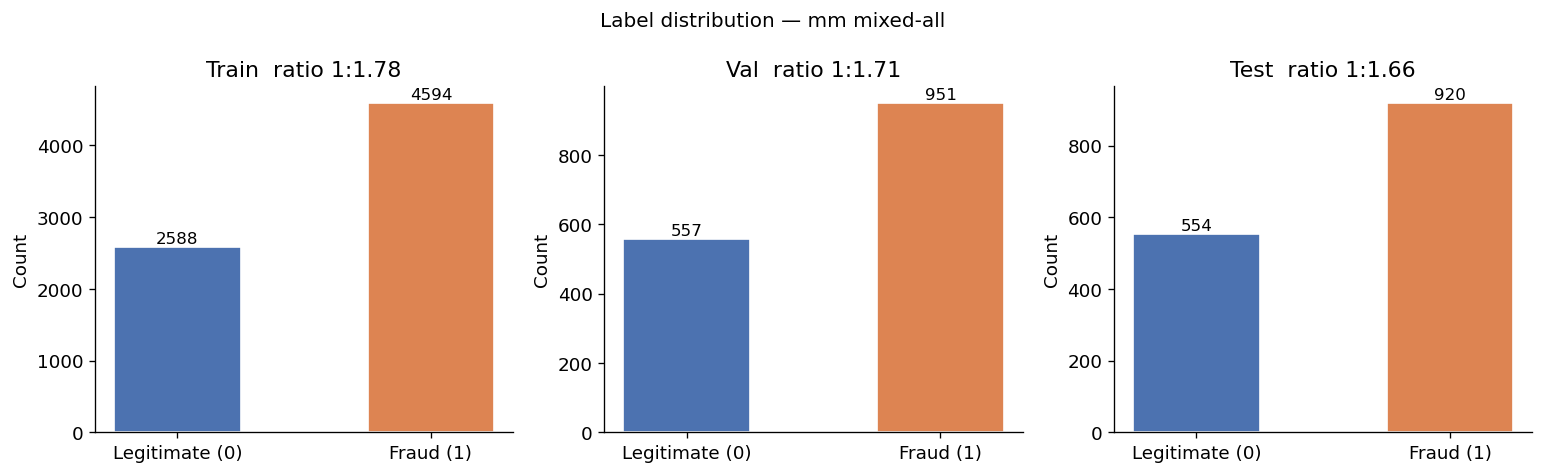

Label imbalance: 2588 legitimate vs 4594 fraud  (ratio 1:1.78)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df) in zip(axes, [("Train",train_df),("Val",val_df),("Test",test_df)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Label distribution — mm mixed-all", fontsize=12)
fig.tight_layout(); plt.show()
n0 = (train_df[TARGET_COL]==0).sum(); n1 = (train_df[TARGET_COL]==1).sum()
print(f"Label imbalance: {n0} legitimate vs {n1} fraud  (ratio 1:{n1/n0:.2f})")


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=50_000, fp_cost=500, save_path=None):
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]
            rgba  = im.cmap(norm(cm_for_color[i,j]))
            lum   = 0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.suptitle(f"{model_name} diagnostics | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
                 fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


---
## Part A  Raw features


In [7]:
X_train_raw = train_df[RAW_COLS]; y_train = train_df[TARGET_COL]
X_val_raw   = val_df[RAW_COLS];   y_val   = val_df[TARGET_COL]
X_test_raw  = test_df[RAW_COLS];  y_test  = test_df[TARGET_COL]

spw = compute_scale_pos_weight(y_train)

print("Features:", list(RAW_COLS))
print("X_train shape:", X_train_raw.shape)
print(f"scale_pos_weight = {spw:.4f}  (n_neg / n_pos)")
print("\nTrain class counts:")
print(y_train.value_counts())


Features: ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
X_train shape: (7182, 8)
scale_pos_weight = 0.5633  (n_neg / n_pos)

Train class counts:
final_label
1    4594
0    2588
Name: count, dtype: int64


## 1. XGBoost - A_none

No imbalance correction. Baseline comparison with XGB-none from tabular model on full dataset. 

In [8]:
import joblib

results_dir = RESULTS_ROOT / "A_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_none_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-A_none model...")
    model_A_none = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-A_none model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_A_none = build_xgb_pipeline(
        preprocessor=preprocessor_raw,
        imbalance_method="none",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw,
    )
    model_A_none = fit_model(model_A_none, X_train_raw, y_train,
                          eval_set=(X_val_raw, y_val))
    joblib.dump(model_A_none, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_none\A_none_model.joblib
Model exists: True
Already trained. Loading saved XGB-A_none model...
Model loaded successfully.


In [9]:
val_metrics_A_none,  val_cm_A_none  = evaluate_model(model_A_none, X_val_raw,  y_val,  split_name="validation_A_none")
test_metrics_A_none, test_cm_A_none = evaluate_model(model_A_none, X_test_raw, y_test, split_name="test_A_none")



=== VALIDATION_A_NONE ===
  accuracy: 0.713528
  precision: 0.843709
  recall: 0.669821
  f1: 0.746776
  roc_auc: 0.791150
  pr_auc: 0.897386

Confusion matrix:
 [[439 118]
 [314 637]]

Classification report:
              precision    recall  f1-score   support

           0     0.5830    0.7882    0.6702       557
           1     0.8437    0.6698    0.7468       951

    accuracy                         0.7135      1508
   macro avg     0.7134    0.7290    0.7085      1508
weighted avg     0.7474    0.7135    0.7185      1508


=== TEST_A_NONE ===
  accuracy: 0.717775
  precision: 0.847107
  recall: 0.668478
  f1: 0.747266
  roc_auc: 0.795363
  pr_auc: 0.898535

Confusion matrix:
 [[443 111]
 [305 615]]

Classification report:
              precision    recall  f1-score   support

           0     0.5922    0.7996    0.6805       554
           1     0.8471    0.6685    0.7473       920

    accuracy                         0.7178      1474
   macro avg     0.7197    0.7341    0.71

The A_none XGBoost model achieved a fraud-class F1-score of 0.7473 on the test set, with precision of 0.8471 and recall of 0.6685. It correctly detected 615 fraud cases and missed 305, while producing 111 false positives. Compared with Logistic Regression on raw features, XGBoost improved legitimate-class detection and reduced false positives, but fraud recall remained limited.

### Threshold tuning for XGBoost A_none

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).


In [10]:
threshold_results_A_none = search_thresholds(model_A_none, X_val_raw, y_val)
print(threshold_results_A_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.630392  0.998948  0.772986             1507
2        0.20   0.630392  0.998948  0.772986             1507
3        0.25   0.630493  0.995794  0.772116             1502
4        0.30   0.634097  0.989485  0.772895             1484
5        0.35   0.650215  0.955836  0.773946             1398
6        0.40   0.689916  0.863302  0.766931             1190
7        0.45   0.757447  0.748686  0.753041              940
8        0.50   0.843709  0.669821  0.746776              755
9        0.55   0.905263  0.633018  0.745050              665
10       0.60   0.929134  0.620400  0.744010              635
11       0.65   0.951060  0.613039  0.745524              613
12       0.70   0.973064  0.607781  0.748220              594
13       0.75   0.975737  0.592008  0.736911              577
14       0.80   0.981917  0.570978  0.722074              553
15      

In [11]:
cost_df_A_none = compute_cost_table(threshold_results_A_none, y_val)
print(cost_df_A_none.head())


   threshold   tp   fp  fn  tn  precision    recall        f1  \
0       0.10  951  557   0   0   0.630637  1.000000  0.773485   
1       0.15  950  557   1   0   0.630392  0.998948  0.772986   
2       0.20  950  557   1   0   0.630392  0.998948  0.772986   
3       0.25  947  555   4   2   0.630493  0.995794  0.772116   
4       0.30  941  543  10  14   0.634097  0.989485  0.772895   

   predicted_fraud  expected_cost  
0             1508         278500  
1             1507         328500  
2             1507         328500  
3             1502         477500  
4             1484         771500  




Threshold tuning was applied to the A_none XGBoost model on the validation set. The lowest expected validation cost is reached at threshold 0.10.

At this threshold, the model detects all 951 fraud cases in the validation set and misses none. However, it also flags all 557 legitimate cases as fraud. This means that the model becomes fully fraud-oriented at the cost-optimal threshold.

The expected validation cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 557 × $500  
Expected cost = $278,500

Although this threshold gives the lowest cost, it produces a degenerate classifier: all validation observations are predicted as fraud. This shows that, for the raw-feature XGBoost model, the cost objective again strongly favours recall over legitimate-class detection.

In [12]:
val_cost_A_none         = compute_expected_cost_from_cm(val_cm_A_none)
default_validation_cost = val_cost_A_none["expected_cost"]
best_validation_cost    = cost_df_A_none.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $15,759,000
Best tuned validation cost: $278,500
Cost reduction:             $15,480,500


### Tuned threshold results for XGBoost A_none

In [13]:
best_threshold_A_none = float(cost_df_A_none.iloc[0]["threshold"])
best_threshold_A_none


0.1

In [14]:
tuned_metrics_A_none, tuned_cm_A_none = evaluate_with_threshold(
    model_A_none, X_test_raw, y_test, best_threshold_A_none)
cost_summary_A_none = compute_expected_cost_from_cm(tuned_cm_A_none)
print(cost_summary_A_none)



Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
   macro avg     0.3121    0.5000    0.3843      1474
weighted avg     0.3896    0.6242    0.4797      1474

{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}




After cost-based threshold tuning, the selected threshold for the A_none XGBoost model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the confusion matrix shows that the model predicts every test sample as fraud. It has zero false negatives, but it also has zero true negatives and 554 false positives. This means that the model completely loses legitimate-class detection under the cost-tuned threshold.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 554 × $500  
Expected cost = $277,000


In [15]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_A_none,
    val_metrics=val_metrics_A_none,
    test_metrics=test_metrics_A_none,
    val_cm=val_cm_A_none,
    test_cm=test_cm_A_none,
    threshold_results=threshold_results_A_none,
    cost_df=cost_df_A_none,
    tuned_metrics=tuned_metrics_A_none,
    tuned_cm=tuned_cm_A_none,
    prefix="A_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_none


In [16]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_none_cost_results.csv',
 'A_none_metrics_summary.csv',
 'A_none_model.joblib',
 'A_none_test_confusion_matrix.csv',
 'A_none_test_metrics.json',
 'A_none_threshold_results.csv',
 'A_none_tuned_test_confusion_matrix.csv',
 'A_none_tuned_test_metrics.json',
 'A_none_validation_confusion_matrix.csv',
 'A_none_validation_metrics.json']

## 2. XGBoost - A_weight

scale_pos_weight = n_neg/n_pos upweights fraud in XGBoost's gradient.

In [17]:
import joblib

results_dir = RESULTS_ROOT / "A_weight"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_weight_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-A_weight model...")
    model_A_weight = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-A_weight model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_A_weight = build_xgb_pipeline(
        preprocessor=preprocessor_raw,
        imbalance_method="scale_pos_weight",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw,
    )
    model_A_weight = fit_model(model_A_weight, X_train_raw, y_train,
                          eval_set=(X_val_raw, y_val))
    joblib.dump(model_A_weight, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_weight\A_weight_model.joblib
Model exists: True
Already trained. Loading saved XGB-A_weight model...
Model loaded successfully.


In [18]:
val_metrics_A_weight,  val_cm_A_weight  = evaluate_model(model_A_weight, X_val_raw,  y_val,  split_name="validation_A_weight")
test_metrics_A_weight, test_cm_A_weight = evaluate_model(model_A_weight, X_test_raw, y_test, split_name="test_A_weight")



=== VALIDATION_A_WEIGHT ===
  accuracy: 0.735411
  precision: 0.940895
  recall: 0.619348
  f1: 0.746988
  roc_auc: 0.785793
  pr_auc: 0.895609

Confusion matrix:
 [[520  37]
 [362 589]]

Classification report:
              precision    recall  f1-score   support

           0     0.5896    0.9336    0.7227       557
           1     0.9409    0.6193    0.7470       951

    accuracy                         0.7354      1508
   macro avg     0.7652    0.7765    0.7349      1508
weighted avg     0.8111    0.7354    0.7380      1508


=== TEST_A_WEIGHT ===
  accuracy: 0.742877
  precision: 0.951586
  recall: 0.619565
  f1: 0.750494
  roc_auc: 0.798990
  pr_auc: 0.900992

Confusion matrix:
 [[525  29]
 [350 570]]

Classification report:
              precision    recall  f1-score   support

           0     0.6000    0.9477    0.7348       554
           1     0.9516    0.6196    0.7505       920

    accuracy                         0.7429      1474
   macro avg     0.7758    0.7836    

The A_weight XGBoost model achieved a fraud-class F1-score of 0.7505 on the test set, with very high precision of 0.9516 but lower recall of 0.6196. It produced only 29 false positives and correctly identified 525 legitimate cases, but it missed 350 fraud cases. This shows that class weighting made XGBoost more conservative: it improved legitimate-class detection but reduced fraud sensitivity.

### Threshold tuning for XGBoost A_weight

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).



In [19]:
threshold_results_A_weight = search_thresholds(model_A_weight, X_val_raw, y_val)
print(threshold_results_A_weight)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.630146  0.997897  0.772487             1506
2        0.20   0.633850  0.988433  0.772391             1483
3        0.25   0.658464  0.928496  0.770506             1341
4        0.30   0.715100  0.791798  0.751497             1053
5        0.35   0.806846  0.694006  0.746184              818
6        0.40   0.879310  0.643533  0.743169              696
7        0.45   0.920123  0.629863  0.747815              651
8        0.50   0.940895  0.619348  0.746988              626
9        0.55   0.965232  0.613039  0.749839              604
10       0.60   0.969697  0.605678  0.745631              594
11       0.65   0.978984  0.587802  0.734560              571
12       0.70   0.980251  0.574132  0.724138              557
13       0.75   0.987156  0.565720  0.719251              545
14       0.80   0.990530  0.549947  0.707235              528
15      

In [20]:
cost_df_A_weight = compute_cost_table(threshold_results_A_weight, y_val)
print(cost_df_A_weight.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  951  557    0    0   0.630637  1.000000  0.773485   
1       0.15  949  557    2    0   0.630146  0.997897  0.772487   
2       0.20  940  543   11   14   0.633850  0.988433  0.772391   
3       0.25  883  458   68   99   0.658464  0.928496  0.770506   
4       0.30  753  300  198  257   0.715100  0.791798  0.751497   

   predicted_fraud  expected_cost  
0             1508         278500  
1             1506         378500  
2             1483         821500  
3             1341        3629000  
4             1053       10050000  




Threshold tuning was applied to the A_weight XGBoost model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects all 951 fraud cases in the validation set and misses none. However, it also flags all 557 legitimate cases as fraud. This means that, although the model is conservative at the default threshold, cost-based tuning makes it fully fraud-oriented.

The expected validation cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 557 × $500  
Expected cost = $278,500



In [21]:
val_cost_A_weight         = compute_expected_cost_from_cm(val_cm_A_weight)
default_validation_cost = val_cost_A_weight["expected_cost"]
best_validation_cost    = cost_df_A_weight.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,118,500
Best tuned validation cost: $278,500
Cost reduction:             $17,840,000


### Tuned threshold results for XGBoost A_weight

In [22]:
best_threshold_A_weight = float(cost_df_A_weight.iloc[0]["threshold"])
best_threshold_A_weight


0.1

In [23]:
tuned_metrics_A_weight, tuned_cm_A_weight = evaluate_with_threshold(
    model_A_weight, X_test_raw, y_test, best_threshold_A_weight)
cost_summary_A_weight = compute_expected_cost_from_cm(tuned_cm_A_weight)
print(cost_summary_A_weight)



Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
   macro avg     0.3121    0.5000    0.3843      1474
weighted avg     0.3896    0.6242    0.4797      1474

{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}




After cost-based threshold tuning, the selected threshold for the A_weight XGBoost model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model also predicts every test sample as fraud. This gives zero false negatives, but it also gives zero true negatives and 554 false positives. Therefore, the model completely loses its ability to identify legitimate cases after cost-based tuning.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 554 × $500  
Expected cost = $277,000

Although the expected cost is low, the macro F1-score is only 0.3843 because the legitimate class is not detected at all. This shows that, for A_weight, cost-based tuning removes the conservative behavior seen at the default threshold and turns the model into an all-fraud classifier.

In [24]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_A_weight,
    val_metrics=val_metrics_A_weight,
    test_metrics=test_metrics_A_weight,
    val_cm=val_cm_A_weight,
    test_cm=test_cm_A_weight,
    threshold_results=threshold_results_A_weight,
    cost_df=cost_df_A_weight,
    tuned_metrics=tuned_metrics_A_weight,
    tuned_cm=tuned_cm_A_weight,
    prefix="A_weight",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_weight


In [25]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_weight_cost_results.csv',
 'A_weight_metrics_summary.csv',
 'A_weight_model.joblib',
 'A_weight_test_confusion_matrix.csv',
 'A_weight_test_metrics.json',
 'A_weight_threshold_results.csv',
 'A_weight_tuned_test_confusion_matrix.csv',
 'A_weight_tuned_test_metrics.json',
 'A_weight_validation_confusion_matrix.csv',
 'A_weight_validation_metrics.json']

## 3. XGBoost - A_smote

SMOTE with strategy=0.1 (conservative - avoids overfitting on synthetic samples).

In [26]:
import joblib

results_dir = RESULTS_ROOT / "A_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_smote_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-A_smote model...")
    model_A_smote = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-A_smote model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_A_smote = build_xgb_pipeline(
        preprocessor=preprocessor_raw,
        imbalance_method="smote",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw, smote_sampling_strategy=0.1,
    )
    model_A_smote = fit_model(model_A_smote, X_train_raw, y_train,
                          eval_set=(X_val_raw, y_val))
    joblib.dump(model_A_smote, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_smote\A_smote_model.joblib
Model exists: True
Already trained. Loading saved XGB-A_smote model...
Model loaded successfully.


In [27]:
val_metrics_A_smote,  val_cm_A_smote  = evaluate_model(model_A_smote, X_val_raw,  y_val,  split_name="validation_A_smote")
test_metrics_A_smote, test_cm_A_smote = evaluate_model(model_A_smote, X_test_raw, y_test, split_name="test_A_smote")



=== VALIDATION_A_SMOTE ===
  accuracy: 0.730106
  precision: 0.925000
  recall: 0.622503
  f1: 0.744186
  roc_auc: 0.791322
  pr_auc: 0.897972

Confusion matrix:
 [[509  48]
 [359 592]]

Classification report:
              precision    recall  f1-score   support

           0     0.5864    0.9138    0.7144       557
           1     0.9250    0.6225    0.7442       951

    accuracy                         0.7301      1508
   macro avg     0.7557    0.7682    0.7293      1508
weighted avg     0.7999    0.7301    0.7332      1508


=== TEST_A_SMOTE ===
  accuracy: 0.744233
  precision: 0.935795
  recall: 0.633696
  f1: 0.755671
  roc_auc: 0.801390
  pr_auc: 0.901592

Confusion matrix:
 [[514  40]
 [337 583]]

Classification report:
              precision    recall  f1-score   support

           0     0.6040    0.9278    0.7317       554
           1     0.9358    0.6337    0.7557       920

    accuracy                         0.7442      1474
   macro avg     0.7699    0.7807    0.

The A_SMOTE XGBoost model achieved the best default-threshold performance among the raw-feature XGBoost variants. On the test set, it reached a fraud-class F1-score of 0.7557, with high precision of 0.9358 and recall of 0.6337. It produced only 40 false positives and correctly identified 514 legitimate cases, but it still missed 337 fraud cases. This shows that SMOTE improves default-threshold balance, but fraud recall remains limited.

### Threshold tuning for XGBoost A_smote

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).
Consistent with notebooks 11 and 12.


In [28]:
threshold_results_A_smote = search_thresholds(model_A_smote, X_val_raw, y_val)
print(threshold_results_A_smote)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.630392  0.998948  0.772986             1507
2        0.20   0.631861  0.992639  0.772188             1494
3        0.25   0.651766  0.950578  0.773311             1387
4        0.30   0.709973  0.815983  0.759295             1093
5        0.35   0.786127  0.715037  0.748899              865
6        0.40   0.851064  0.672976  0.751615              752
7        0.45   0.901325  0.643533  0.750920              679
8        0.50   0.925000  0.622503  0.744186              640
9        0.55   0.954248  0.614090  0.747281              612
10       0.60   0.968121  0.606730  0.745960              596
11       0.65   0.970639  0.590957  0.734641              579
12       0.70   0.978610  0.577287  0.726190              561
13       0.75   0.987037  0.560463  0.714956              540
14       0.80   0.990458  0.545741  0.703729              524
15      

In [29]:
cost_df_A_smote = compute_cost_table(threshold_results_A_smote, y_val)
print(cost_df_A_smote.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  951  557    0    0   0.630637  1.000000  0.773485   
1       0.15  950  557    1    0   0.630392  0.998948  0.772986   
2       0.20  944  550    7    7   0.631861  0.992639  0.772188   
3       0.25  904  483   47   74   0.651766  0.950578  0.773311   
4       0.30  776  317  175  240   0.709973  0.815983  0.759295   

   predicted_fraud  expected_cost  
0             1508         278500  
1             1507         328500  
2             1494         625000  
3             1387        2591500  
4             1093        8908500  



Threshold tuning was applied to the A_SMOTE XGBoost model using the validation set. The lowest expected validation cost is reached at threshold 0.10.

At this threshold, the model detects all 951 fraud cases in the validation set and misses none. However, it also classifies all 557 legitimate cases as fraud. This means that cost-based tuning again pushes the model into an all-fraud prediction strategy.

The expected validation cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 557 × $500  
Expected cost = $278,500



In [30]:
val_cost_A_smote         = compute_expected_cost_from_cm(val_cm_A_smote)
default_validation_cost = val_cost_A_smote["expected_cost"]
best_validation_cost    = cost_df_A_smote.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $17,974,000
Best tuned validation cost: $278,500
Cost reduction:             $17,695,500


### Tuned threshold results for XGBoost A_smote

In [31]:
best_threshold_A_smote = float(cost_df_A_smote.iloc[0]["threshold"])
best_threshold_A_smote


0.1

In [32]:
tuned_metrics_A_smote, tuned_cm_A_smote = evaluate_with_threshold(
    model_A_smote, X_test_raw, y_test, best_threshold_A_smote)
cost_summary_A_smote = compute_expected_cost_from_cm(tuned_cm_A_smote)
print(cost_summary_A_smote)



Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
   macro avg     0.3121    0.5000    0.3843      1474
weighted avg     0.3896    0.6242    0.4797      1474

{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}




After cost-based threshold tuning, the selected threshold for the A_SMOTE XGBoost model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model also predicts every test sample as fraud. This produces zero false negatives, but also zero true negatives and 554 false positives. As a result, the model completely loses legitimate-class detection under the cost-tuned threshold.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 554 × $500  
Expected cost = $277,000



In [33]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_A_smote,
    val_metrics=val_metrics_A_smote,
    test_metrics=test_metrics_A_smote,
    val_cm=val_cm_A_smote,
    test_cm=test_cm_A_smote,
    threshold_results=threshold_results_A_smote,
    cost_df=cost_df_A_smote,
    tuned_metrics=tuned_metrics_A_smote,
    tuned_cm=tuned_cm_A_smote,
    prefix="A_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\A_smote


In [34]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_smote_cost_results.csv',
 'A_smote_metrics_summary.csv',
 'A_smote_model.joblib',
 'A_smote_test_confusion_matrix.csv',
 'A_smote_test_metrics.json',
 'A_smote_threshold_results.csv',
 'A_smote_tuned_test_confusion_matrix.csv',
 'A_smote_tuned_test_metrics.json',
 'A_smote_validation_confusion_matrix.csv',
 'A_smote_validation_metrics.json']

## Comparison  Part A  raw features

In [36]:
comparison_a = pd.DataFrame([
    {
        "model": "A_none",
        "val_f1": val_metrics_A_none["f1"],
        "val_roc_auc": val_metrics_A_none["roc_auc"],
        "val_pr_auc": val_metrics_A_none["pr_auc"],
        "test_f1": test_metrics_A_none["f1"],
        "test_roc_auc": test_metrics_A_none["roc_auc"],
        "test_pr_auc": test_metrics_A_none["pr_auc"],
        "best_threshold": best_threshold_A_none,
        "tuned_test_precision": tuned_metrics_A_none["precision"],
        "tuned_test_recall": tuned_metrics_A_none["recall"],
        "tuned_test_f1": tuned_metrics_A_none["f1"],
        "tuned_expected_cost": cost_summary_A_none["expected_cost"],
    },
    {
        "model": "A_weight",
        "val_f1": val_metrics_A_weight["f1"],
        "val_roc_auc": val_metrics_A_weight["roc_auc"],
        "val_pr_auc": val_metrics_A_weight["pr_auc"],
        "test_f1": test_metrics_A_weight["f1"],
        "test_roc_auc": test_metrics_A_weight["roc_auc"],
        "test_pr_auc": test_metrics_A_weight["pr_auc"],
        "best_threshold": best_threshold_A_weight,
        "tuned_test_precision": tuned_metrics_A_weight["precision"],
        "tuned_test_recall": tuned_metrics_A_weight["recall"],
        "tuned_test_f1": tuned_metrics_A_weight["f1"],
        "tuned_expected_cost": cost_summary_A_weight["expected_cost"],
    },
    {
        "model": "A_smote",
        "val_f1": val_metrics_A_smote["f1"],
        "val_roc_auc": val_metrics_A_smote["roc_auc"],
        "val_pr_auc": val_metrics_A_smote["pr_auc"],
        "test_f1": test_metrics_A_smote["f1"],
        "test_roc_auc": test_metrics_A_smote["roc_auc"],
        "test_pr_auc": test_metrics_A_smote["pr_auc"],
        "best_threshold": best_threshold_A_smote,
        "tuned_test_precision": tuned_metrics_A_smote["precision"],
        "tuned_test_recall": tuned_metrics_A_smote["recall"],
        "tuned_test_f1": tuned_metrics_A_smote["f1"],
        "tuned_expected_cost": cost_summary_A_smote["expected_cost"],
    },
])

comparison_a


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,A_none,0.746776,0.791150,0.897386,0.747266,0.795363,0.898535,0.1,0.624152,1.0,0.768588,277000
1,A_weight,0.746988,0.785793,0.895609,0.750494,0.798990,0.900992,0.1,0.624152,1.0,0.768588,277000
2,A_smote,0.744186,0.791322,0.897972,0.755671,0.801390,0.901592,0.1,0.624152,1.0,0.768588,277000


In [37]:
comparison_a.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,A_none,0.1,0.624152,1.0,0.768588,277000
1,A_weight,0.1,0.624152,1.0,0.768588,277000
2,A_smote,0.1,0.624152,1.0,0.768588,277000


## Comparison bar chart  Part A  raw features

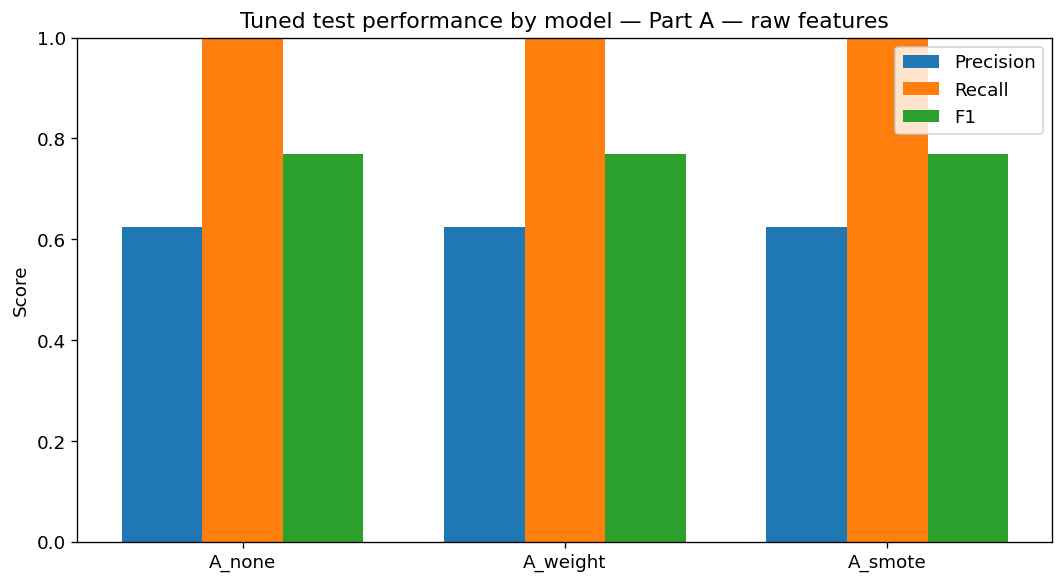

In [38]:
import numpy as np
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_a["model"])); width = 0.25
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_a[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_a["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model — Part A — raw features")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison 

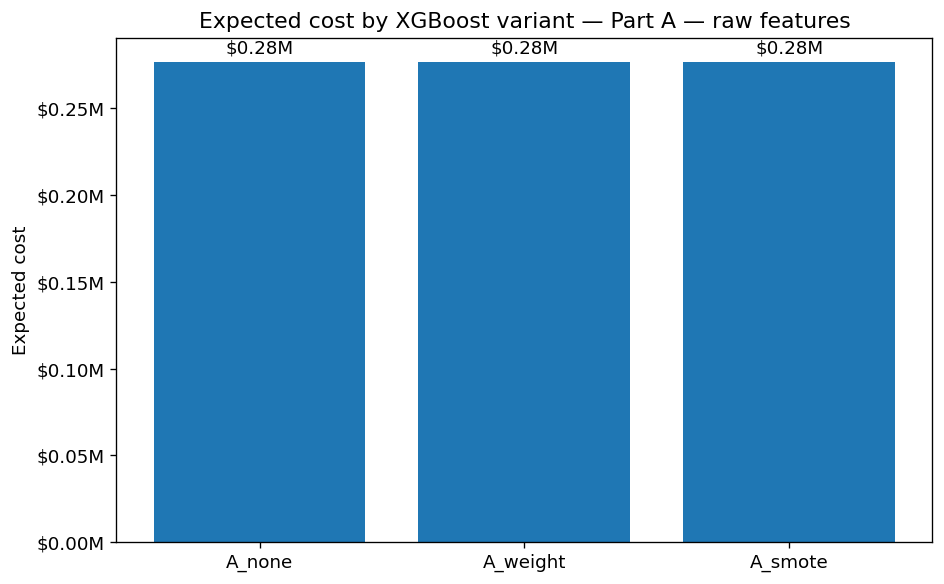

In [39]:
from matplotlib.ticker import FuncFormatter
cost_plot_df = comparison_a.sort_values("tuned_expected_cost")
plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by XGBoost variant — Part A — raw features")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout(); plt.show()


## Threshold performance plot 

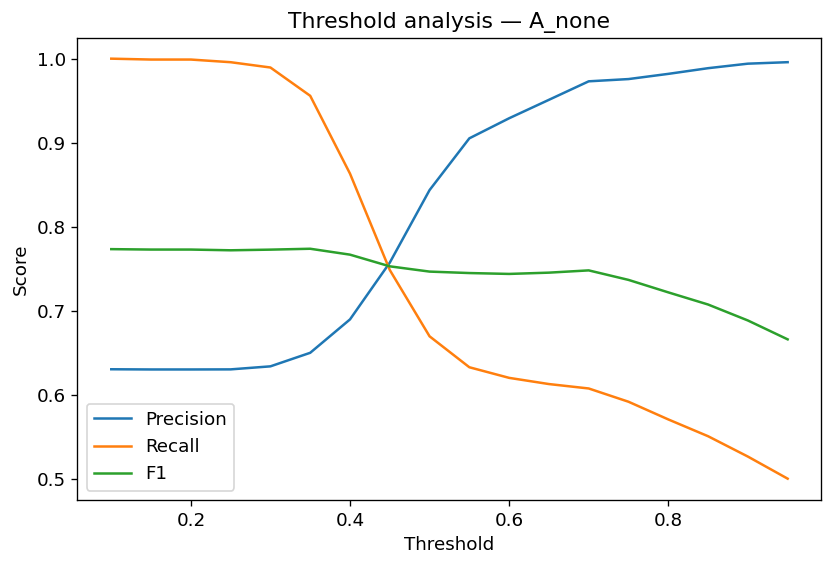

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["precision"], label="Precision")
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["recall"],    label="Recall")
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["f1"],        label="F1")
plt.title("Threshold analysis — A_none")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices 

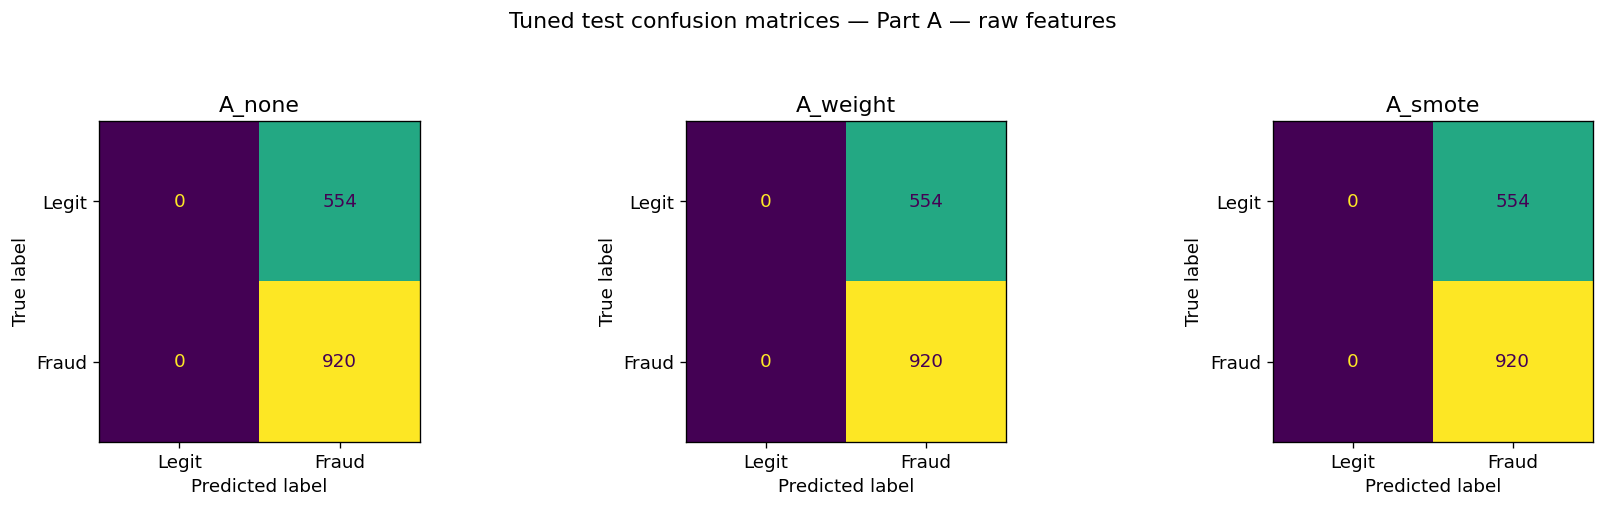

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_A_none, "A_none"), (tuned_cm_A_weight, "A_weight"), (tuned_cm_A_smote, "A_smote")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices — Part A — raw features", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis 

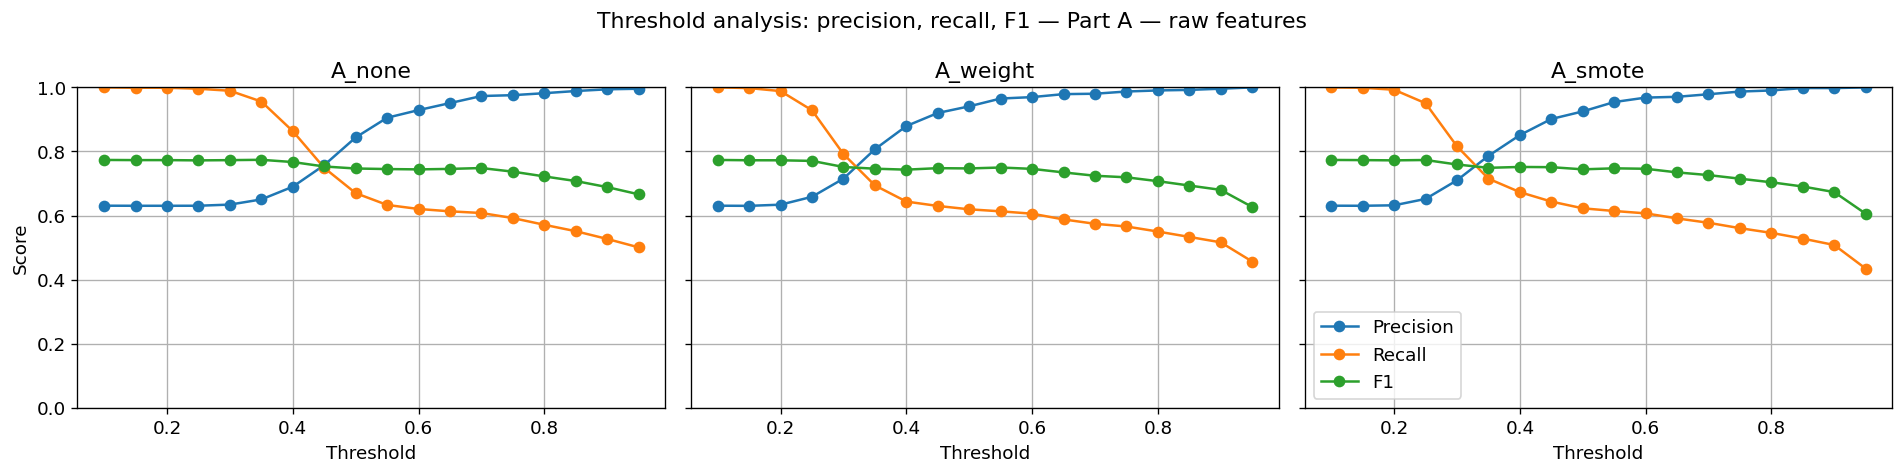

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_A_none, "A_none"), (threshold_results_A_weight, "A_weight"), (threshold_results_A_smote, "A_smote")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1 — Part A — raw features")
plt.tight_layout(); plt.show()


## Expected cost by threshold 

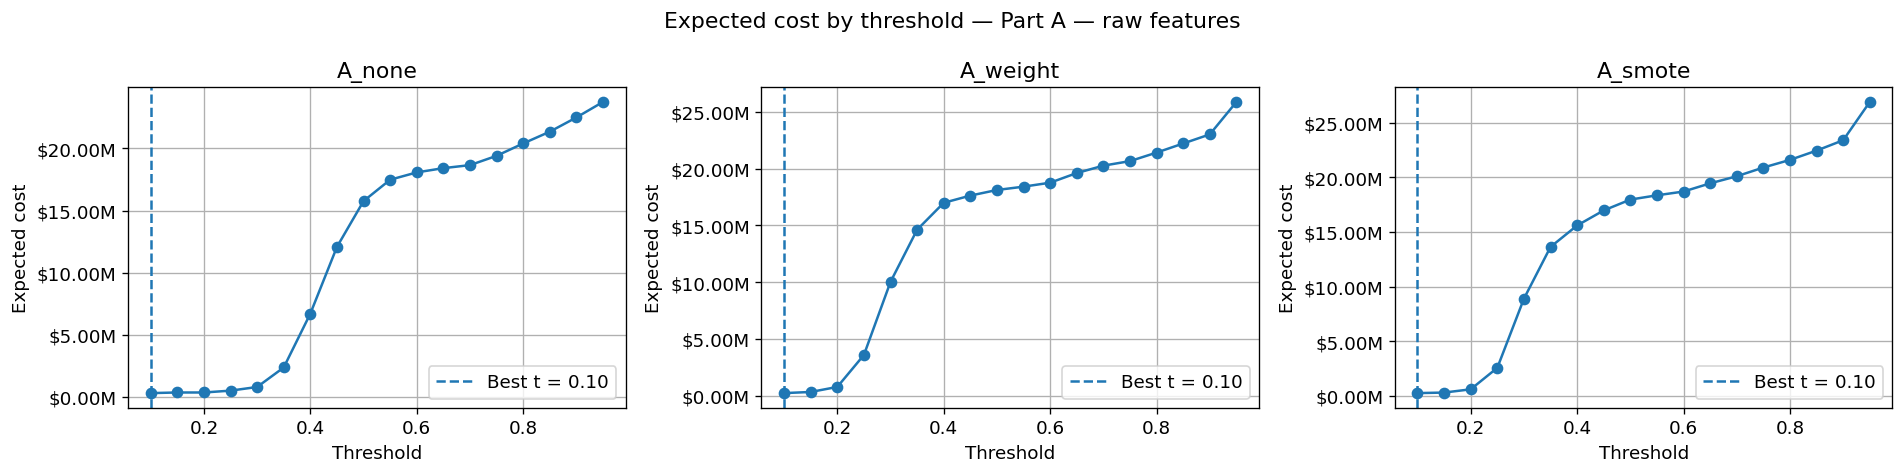

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_A_none, "A_none"), (cost_df_A_weight, "A_weight"), (cost_df_A_smote, "A_smote")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part A — raw features")
plt.tight_layout(); plt.show()


## Precision-Recall curves 

In [44]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(X_val_raw, model_A_none.predict_proba(X_val_raw)[:, 1])
p_1, r_1, _ = precision_recall_curve(X_val_raw, model_A_weight.predict_proba(X_val_raw)[:, 1])
p_2, r_2, _ = precision_recall_curve(X_val_raw, model_A_smote.predict_proba(X_val_raw)[:, 1])
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, label="A_none")
plt.plot(r_1, p_1, label="A_weight")
plt.plot(r_2, p_2, label="A_smote")
plt.title("Precision-Recall curves — Part A — raw features")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


ValueError: continuous-multioutput format is not supported

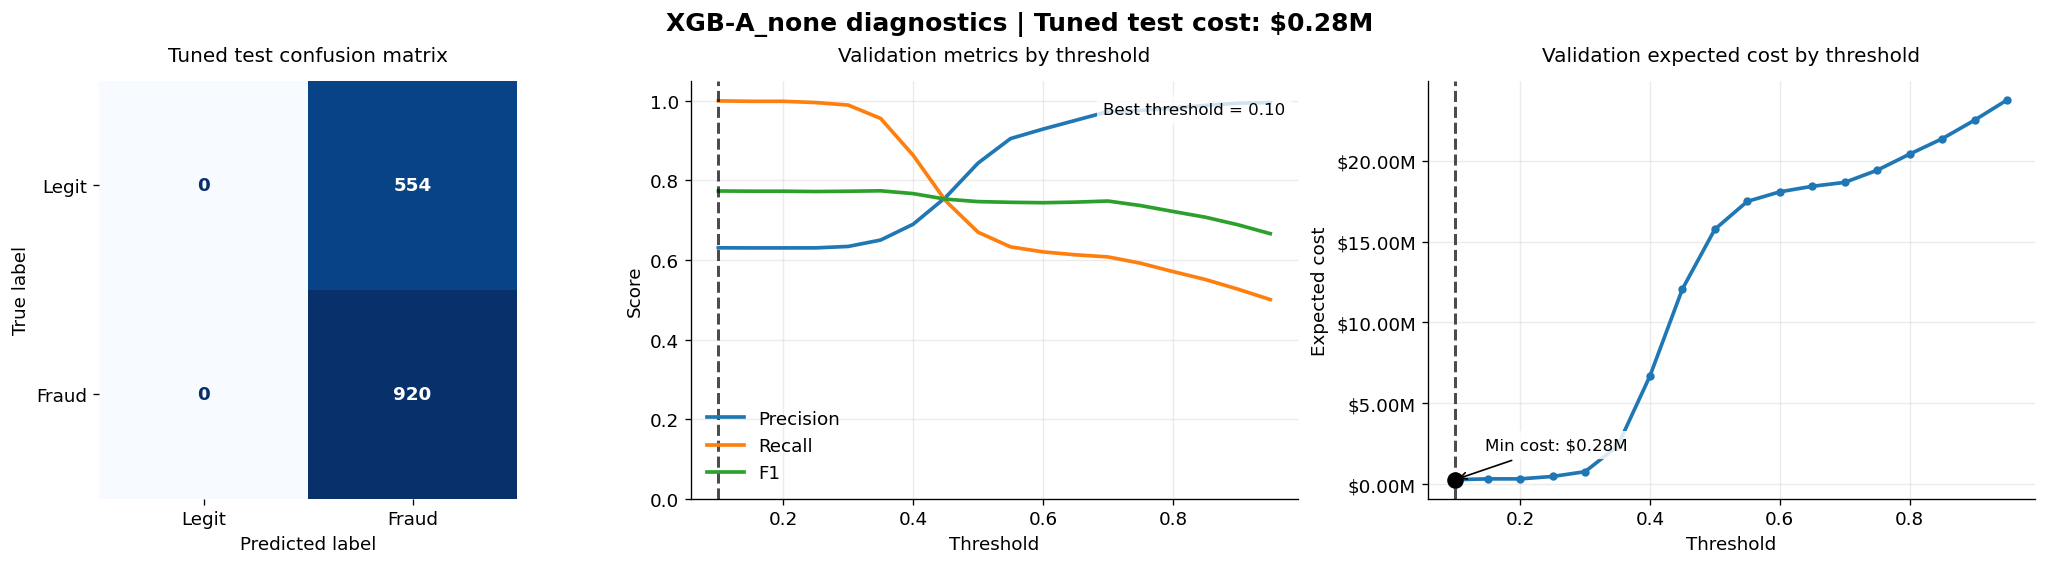

In [45]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_none,
    threshold_results=threshold_results_A_none,
    cost_df=cost_df_A_none,
    model_name="XGB-A_none",
    save_path=RESULTS_ROOT / "diagnostics_A_none.png",
)


The XGB-A_none model selects threshold 0.10 and predicts all test samples as fraud. This removes false negatives and gives a low expected cost of about $0.28M, but it also produces 554 false positives and zero true negatives. Therefore, the result is cost-efficient but degenerate: the model minimizes missed fraud, but it does not distinguish legitimate cases.

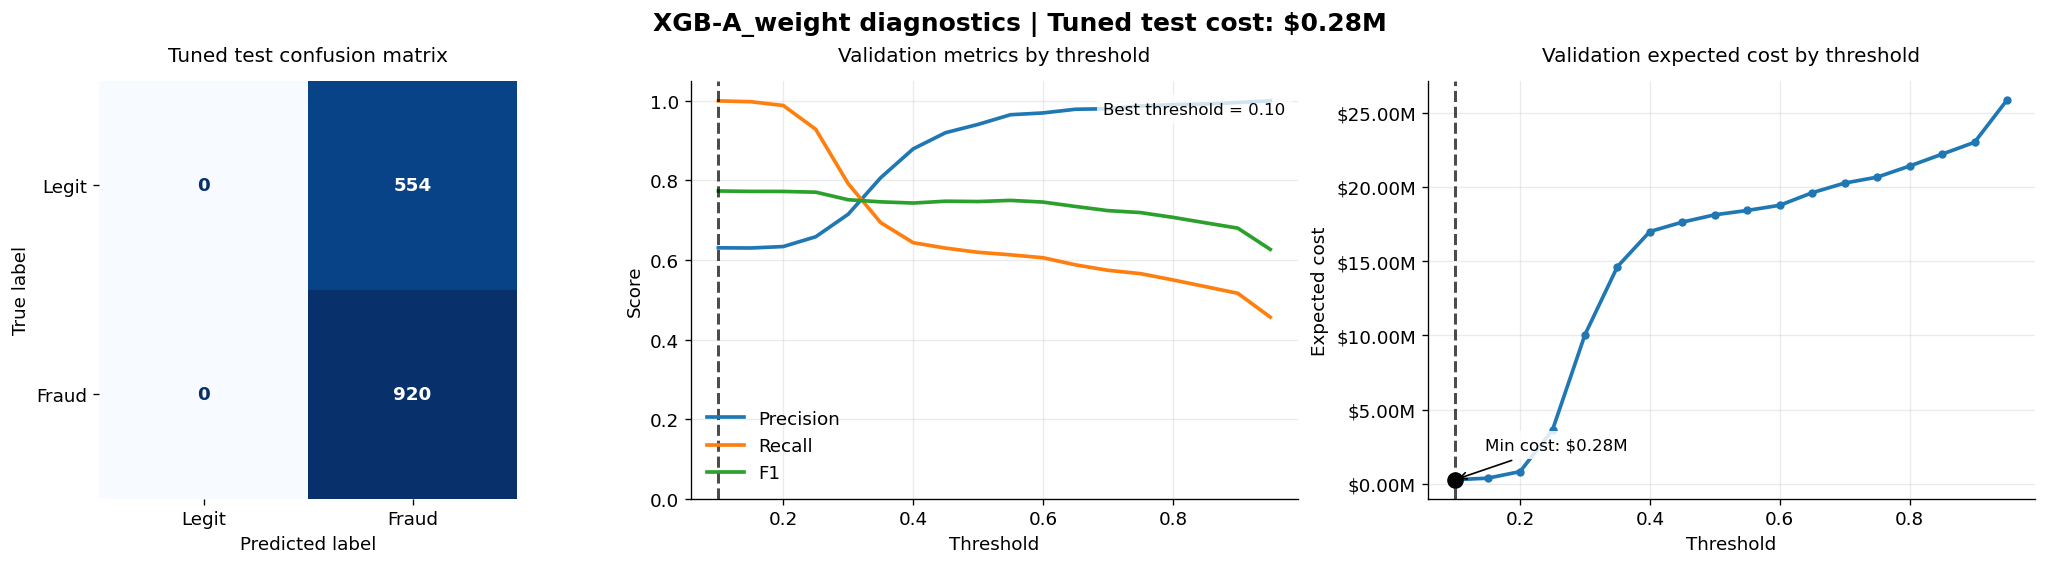

In [98]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_weight,
    threshold_results=threshold_results_A_weight,
    cost_df=cost_df_A_weight,
    model_name="XGB-A_weight",
    save_path=RESULTS_ROOT / "diagnostics_A_weight.png",
)


XGB-A_weight also selects threshold 0.10 and predicts all test samples as fraud. This gives zero false negatives and a low expected cost of about $0.28M, but it also produces 554 false positives and zero true negatives. Therefore, class weighting does not prevent the cost-tuned raw-feature XGBoost model from collapsing into an all-fraud classifier.

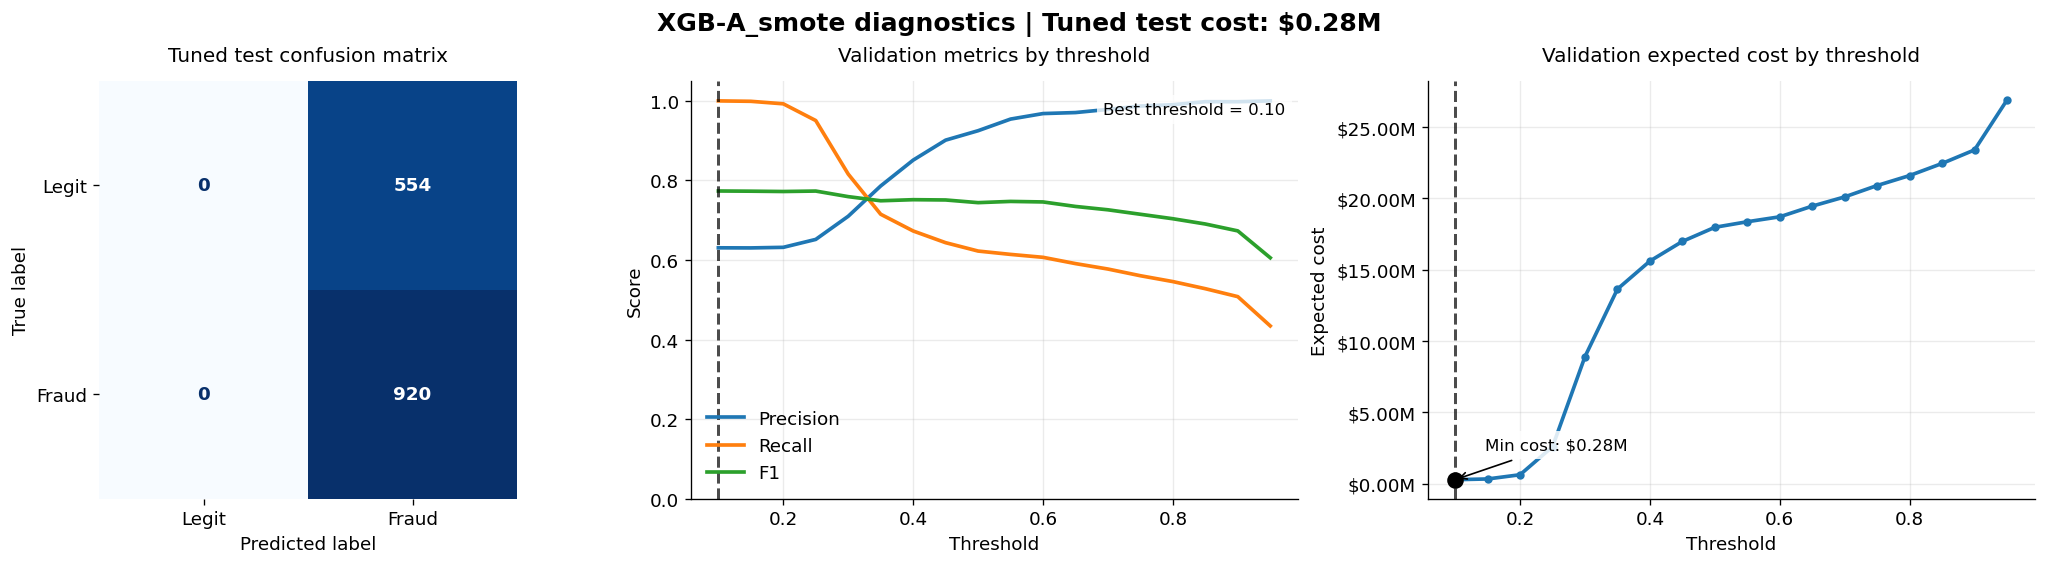

In [99]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_smote,
    threshold_results=threshold_results_A_smote,
    cost_df=cost_df_A_smote,
    model_name="XGB-A_smote",
    save_path=RESULTS_ROOT / "diagnostics_A_smote.png",
)


XGB-A_smote also selects threshold 0.10 and predicts all observations as fraud. This eliminates false negatives and gives a low expected cost of about $0.28M, but it also produces 554 false positives and zero true negatives. Therefore, SMOTE does not prevent the raw-feature XGBoost model from collapsing into an all-fraud strategy under cost-based tuning.

## Final choice  Part A  raw features

In [48]:
final_a = comparison_a.sort_values("tuned_expected_cost").copy()
final_a


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,A_none,0.746776,0.791150,0.897386,0.747266,0.795363,0.898535,0.1,0.624152,1.0,0.768588,277000
1,A_weight,0.746988,0.785793,0.895609,0.750494,0.798990,0.900992,0.1,0.624152,1.0,0.768588,277000
2,A_smote,0.744186,0.791322,0.897972,0.755671,0.801390,0.901592,0.1,0.624152,1.0,0.768588,277000


---
## Part B - Engineered features
Adds  balance-delta/ratio features. 

In [49]:
train_fe = engineer_features(train_df)
val_fe   = engineer_features(val_df)
test_fe  = engineer_features(test_df)

X_train_fe = train_fe[FE_COLS]
X_val_fe   = val_fe[FE_COLS]
X_test_fe  = test_fe[FE_COLS]

spw_fe = compute_scale_pos_weight(y_train)

print("Features:", list(FE_COLS))
print("X_train shape:", X_train_fe.shape)
print(f"scale_pos_weight = {spw_fe:.4f}")


Features: ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']
X_train shape: (7182, 13)
scale_pos_weight = 0.5633


In [50]:
preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
preprocessor_fe


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['tab_step', 'tab_amount', 'tab_oldbalanceOrg',
                                  'tab_newbalanceOrig', 'tab_oldbalanceDest',
                                  'tab_newbalanceDest', 'tab_isFlaggedFraud',
                                  'tab_balance_delta_orig',
                                  'tab_balance_delta_dest',
                                  'tab_amount_ratio_orig',
                                  'tab_amount_ratio_dest',
                                  'tab_orig_balance_zeroed']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['tab_type'])])

## 4. XGBoost — B_none

No imbalance correction, engineered features.

In [51]:
import joblib

results_dir = RESULTS_ROOT / "B_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_none_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-B_none model...")
    model_B_none = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-B_none model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_B_none = build_xgb_pipeline(
        preprocessor=preprocessor_fe,
        imbalance_method="none",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw_fe,
    )
    model_B_none = fit_model(model_B_none, X_train_fe, y_train,
                          eval_set=(X_val_fe, y_val))
    joblib.dump(model_B_none, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_none\B_none_model.joblib
Model exists: True
Already trained. Loading saved XGB-B_none model...
Model loaded successfully.


In [52]:
val_metrics_B_none,  val_cm_B_none  = evaluate_model(model_B_none, X_val_fe,  y_val,  split_name="validation_B_none")
test_metrics_B_none, test_cm_B_none = evaluate_model(model_B_none, X_test_fe, y_test, split_name="test_B_none")



=== VALIDATION_B_NONE ===
  accuracy: 0.722812
  precision: 0.873773
  recall: 0.655100
  f1: 0.748798
  roc_auc: 0.786112
  pr_auc: 0.897102

Confusion matrix:
 [[467  90]
 [328 623]]

Classification report:
              precision    recall  f1-score   support

           0     0.5874    0.8384    0.6908       557
           1     0.8738    0.6551    0.7488       951

    accuracy                         0.7228      1508
   macro avg     0.7306    0.7468    0.7198      1508
weighted avg     0.7680    0.7228    0.7274      1508


=== TEST_B_NONE ===
  accuracy: 0.734057
  precision: 0.895210
  recall: 0.650000
  f1: 0.753149
  roc_auc: 0.802141
  pr_auc: 0.901974

Confusion matrix:
 [[484  70]
 [322 598]]

Classification report:
              precision    recall  f1-score   support

           0     0.6005    0.8736    0.7118       554
           1     0.8952    0.6500    0.7531       920

    accuracy                         0.7341      1474
   macro avg     0.7479    0.7618    0.73

The B_none XGBoost model achieved a fraud-class F1-score of 0.7531 on the test set, with precision of 0.8952 and recall of 0.6500. It correctly detected 598 fraud cases and missed 322, while producing 70 false positives. Compared with the raw-feature A_none model, engineered features improved precision, reduced false positives, and slightly improved ROC-AUC and PR-AUC, but fraud recall remained limited.

### Threshold tuning for XGBoost B_none

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).
Consistent with notebooks 11 and 12.


In [53]:
threshold_results_B_none = search_thresholds(model_B_none, X_val_fe, y_val)
print(threshold_results_B_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.630637  1.000000  0.773485             1508
2        0.20   0.630392  0.998948  0.772986             1507
3        0.25   0.630984  0.997897  0.773116             1504
4        0.30   0.632107  0.993691  0.772690             1495
5        0.35   0.639103  0.958991  0.767031             1427
6        0.40   0.687069  0.838065  0.755092             1160
7        0.45   0.779030  0.726604  0.751904              887
8        0.50   0.873773  0.655100  0.748798              713
9        0.55   0.942492  0.620400  0.748256              626
10       0.60   0.976271  0.605678  0.747567              590
11       0.65   0.994810  0.604627  0.752126              578
12       0.70   0.996516  0.601472  0.750164              574
13       0.75   1.000000  0.599369  0.749507              570
14       0.80   1.000000  0.598318  0.748684              569
15      

In [54]:
cost_df_B_none = compute_cost_table(threshold_results_B_none, y_val)
print(cost_df_B_none.head())


   threshold   tp   fp  fn  tn  precision    recall        f1  \
0       0.10  951  557   0   0   0.630637  1.000000  0.773485   
1       0.15  951  557   0   0   0.630637  1.000000  0.773485   
2       0.20  950  557   1   0   0.630392  0.998948  0.772986   
3       0.25  949  555   2   2   0.630984  0.997897  0.773116   
4       0.30  945  550   6   7   0.632107  0.993691  0.772690   

   predicted_fraud  expected_cost  
0             1508         278500  
1             1508         278500  
2             1507         328500  
3             1504         377500  
4             1495         575000  




Threshold tuning was applied to the B_none XGBoost model using the validation set. The lowest expected validation cost is achieved at thresholds 0.10 and 0.15. Both thresholds give the same result: all fraud cases are detected, but all legitimate cases are also classified as fraud.

At threshold 0.10, the model detects all 951 fraud cases and misses none. However, it also produces 557 false positives and correctly identifies no legitimate cases. The expected validation cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 557 × $500  
Expected cost = $278,500



In [55]:
val_cost_B_none         = compute_expected_cost_from_cm(val_cm_B_none)
default_validation_cost = val_cost_B_none["expected_cost"]
best_validation_cost    = cost_df_B_none.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $16,445,000
Best tuned validation cost: $278,500
Cost reduction:             $16,166,500


### Tuned threshold results for XGBoost B_none

In [56]:
best_threshold_B_none = float(cost_df_B_none.iloc[0]["threshold"])
best_threshold_B_none


0.1

In [57]:
tuned_metrics_B_none, tuned_cm_B_none = evaluate_with_threshold(
    model_B_none, X_test_fe, y_test, best_threshold_B_none)
cost_summary_B_none = compute_expected_cost_from_cm(tuned_cm_B_none)
print(cost_summary_B_none)



Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
   macro avg     0.3121    0.5000    0.3843      1474
weighted avg     0.3896    0.6242    0.4797      1474

{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}




After cost-based threshold tuning, the selected threshold for the B_none XGBoost model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model also classifies every legitimate case as fraud. The confusion matrix shows 0 true negatives and 554 false positives. This means that, although the model removes false negatives completely, it loses all ability to identify legitimate transactions.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 554 × $500  
Expected cost = $277,000



In [58]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_B_none,
    val_metrics=val_metrics_B_none,
    test_metrics=test_metrics_B_none,
    val_cm=val_cm_B_none,
    test_cm=test_cm_B_none,
    threshold_results=threshold_results_B_none,
    cost_df=cost_df_B_none,
    tuned_metrics=tuned_metrics_B_none,
    tuned_cm=tuned_cm_B_none,
    prefix="B_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_none


In [59]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_none_cost_results.csv',
 'B_none_metrics_summary.csv',
 'B_none_model.joblib',
 'B_none_test_confusion_matrix.csv',
 'B_none_test_metrics.json',
 'B_none_threshold_results.csv',
 'B_none_tuned_test_confusion_matrix.csv',
 'B_none_tuned_test_metrics.json',
 'B_none_validation_confusion_matrix.csv',
 'B_none_validation_metrics.json']

## 5. XGBoost - B_weight

scale_pos_weight with engineered features.

In [60]:
import joblib

results_dir = RESULTS_ROOT / "B_weight"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_weight_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-B_weight model...")
    model_B_weight = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-B_weight model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_B_weight = build_xgb_pipeline(
        preprocessor=preprocessor_fe,
        imbalance_method="scale_pos_weight",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw_fe,
    )
    model_B_weight = fit_model(model_B_weight, X_train_fe, y_train,
                          eval_set=(X_val_fe, y_val))
    joblib.dump(model_B_weight, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_weight\B_weight_model.joblib
Model exists: True
Already trained. Loading saved XGB-B_weight model...
Model loaded successfully.


In [61]:
val_metrics_B_weight,  val_cm_B_weight  = evaluate_model(model_B_weight, X_val_fe,  y_val,  split_name="validation_B_weight")
test_metrics_B_weight, test_cm_B_weight = evaluate_model(model_B_weight, X_test_fe, y_test, split_name="test_B_weight")



=== VALIDATION_B_WEIGHT ===
  accuracy: 0.743369
  precision: 0.973154
  recall: 0.609884
  f1: 0.749838
  roc_auc: 0.784460
  pr_auc: 0.896451

Confusion matrix:
 [[541  16]
 [371 580]]

Classification report:
              precision    recall  f1-score   support

           0     0.5932    0.9713    0.7366       557
           1     0.9732    0.6099    0.7498       951

    accuracy                         0.7434      1508
   macro avg     0.7832    0.7906    0.7432      1508
weighted avg     0.8328    0.7434    0.7449      1508


=== TEST_B_WEIGHT ===
  accuracy: 0.744912
  precision: 0.977193
  recall: 0.605435
  f1: 0.747651
  roc_auc: 0.799320
  pr_auc: 0.900616

Confusion matrix:
 [[541  13]
 [363 557]]

Classification report:
              precision    recall  f1-score   support

           0     0.5985    0.9765    0.7421       554
           1     0.9772    0.6054    0.7477       920

    accuracy                         0.7449      1474
   macro avg     0.7878    0.7910    

The B_weight XGBoost model achieved very high precision of 0.9772 on the test set, but recall was only 0.6054. It produced only 13 false positives and correctly identified 541 legitimate cases, but missed 363 fraud cases. This shows that class weighting with engineered features made XGBoost highly conservative: it improved legitimate-class detection, but reduced fraud sensitivity.

### Threshold tuning for XGBoost B_weight

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).
Consistent with notebooks 11 and 12.


In [62]:
threshold_results_B_weight = search_thresholds(model_B_weight, X_val_fe, y_val)
print(threshold_results_B_weight)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.630392  0.998948  0.772986             1507
2        0.20   0.634706  0.988433  0.773026             1481
3        0.25   0.656841  0.913775  0.764292             1323
4        0.30   0.720347  0.785489  0.751509             1037
5        0.35   0.828025  0.683491  0.748848              785
6        0.40   0.910470  0.630915  0.745342              659
7        0.45   0.943730  0.617245  0.746345              622
8        0.50   0.973154  0.609884  0.749838              596
9        0.55   0.989655  0.603575  0.749837              580
10       0.60   0.994792  0.602524  0.750491              576
11       0.65   0.998249  0.599369  0.749014              571
12       0.70   1.000000  0.599369  0.749507              570
13       0.75   1.000000  0.599369  0.749507              570
14       0.80   1.000000  0.598318  0.748684              569
15      

In [63]:
cost_df_B_weight = compute_cost_table(threshold_results_B_weight, y_val)
print(cost_df_B_weight.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  951  557    0    0   0.630637  1.000000  0.773485   
1       0.15  950  557    1    0   0.630392  0.998948  0.772986   
2       0.20  940  541   11   16   0.634706  0.988433  0.773026   
3       0.25  869  454   82  103   0.656841  0.913775  0.764292   
4       0.30  747  290  204  267   0.720347  0.785489  0.751509   

   predicted_fraud  expected_cost  
0             1508         278500  
1             1507         328500  
2             1481         820500  
3             1323        4327000  
4             1037       10345000  




Threshold tuning was applied to the B_weigh XGBoost model using the validation set. The lowest expected validation cost is again achieved at threshold 0.10.

At this threshold, the model detects all 951 fraud cases and misses none. However, it also classifies all 557 legitimate cases as fraud. This means that the cost-tuned model becomes fully fraud-oriented, even though the default-threshold model was very conservative.

The expected validation cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 557 × $500  
Expected cost = $278,500



In [64]:
val_cost_B_weight         = compute_expected_cost_from_cm(val_cm_B_weight)
default_validation_cost = val_cost_B_weight["expected_cost"]
best_validation_cost    = cost_df_B_weight.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,558,000
Best tuned validation cost: $278,500
Cost reduction:             $18,279,500


### Tuned threshold results for XGBoost B_weight

In [65]:
best_threshold_B_weight = float(cost_df_B_weight.iloc[0]["threshold"])
best_threshold_B_weight


0.1

In [66]:
tuned_metrics_B_weight, tuned_cm_B_weight = evaluate_with_threshold(
    model_B_weight, X_test_fe, y_test, best_threshold_B_weight)
cost_summary_B_weight = compute_expected_cost_from_cm(tuned_cm_B_weight)
print(cost_summary_B_weight)



Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
   macro avg     0.3121    0.5000    0.3843      1474
weighted avg     0.3896    0.6242    0.4797      1474

{'tp': 920, 'fp': 554, 'fn': 0, 'tn': 0, 'expected_cost': 277000}


The cost-tuned B_weight XGBoost model selected threshold 0.10. It detected all fraud cases and achieved an expected cost of $277,000, but it also classified all legitimate cases as fraud. This shows that cost-based tuning overrides the conservative default-threshold behavior of the weighted model and turns it into an all-fraud classifier.

In [67]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_B_weight,
    val_metrics=val_metrics_B_weight,
    test_metrics=test_metrics_B_weight,
    val_cm=val_cm_B_weight,
    test_cm=test_cm_B_weight,
    threshold_results=threshold_results_B_weight,
    cost_df=cost_df_B_weight,
    tuned_metrics=tuned_metrics_B_weight,
    tuned_cm=tuned_cm_B_weight,
    prefix="B_weight",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_weight


In [68]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_weight_cost_results.csv',
 'B_weight_metrics_summary.csv',
 'B_weight_model.joblib',
 'B_weight_test_confusion_matrix.csv',
 'B_weight_test_metrics.json',
 'B_weight_threshold_results.csv',
 'B_weight_tuned_test_confusion_matrix.csv',
 'B_weight_tuned_test_metrics.json',
 'B_weight_validation_confusion_matrix.csv',
 'B_weight_validation_metrics.json']

## 6. XGBoost  B_smote

SMOTE (strategy=0.1) with engineered features.

In [69]:
import joblib

results_dir = RESULTS_ROOT / "B_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_smote_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-B_smote model...")
    model_B_smote = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-B_smote model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_B_smote = build_xgb_pipeline(
        preprocessor=preprocessor_fe,
        imbalance_method="smote",
        random_state=RANDOM_STATE,
        scale_pos_weight=spw_fe, smote_sampling_strategy=0.1,
    )
    model_B_smote = fit_model(model_B_smote, X_train_fe, y_train,
                          eval_set=(X_val_fe, y_val))
    joblib.dump(model_B_smote, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_smote\B_smote_model.joblib
Model exists: True
Already trained. Loading saved XGB-B_smote model...
Model loaded successfully.


In [70]:
val_metrics_B_smote,  val_cm_B_smote  = evaluate_model(model_B_smote, X_val_fe,  y_val,  split_name="validation_B_smote")
test_metrics_B_smote, test_cm_B_smote = evaluate_model(model_B_smote, X_test_fe, y_test, split_name="test_B_smote")



=== VALIDATION_B_SMOTE ===
  accuracy: 0.740716
  precision: 0.962046
  recall: 0.613039
  f1: 0.748876
  roc_auc: 0.789667
  pr_auc: 0.898248

Confusion matrix:
 [[534  23]
 [368 583]]

Classification report:
              precision    recall  f1-score   support

           0     0.5920    0.9587    0.7320       557
           1     0.9620    0.6130    0.7489       951

    accuracy                         0.7407      1508
   macro avg     0.7770    0.7859    0.7404      1508
weighted avg     0.8254    0.7407    0.7426      1508


=== TEST_B_SMOTE ===
  accuracy: 0.749661
  precision: 0.979130
  recall: 0.611957
  f1: 0.753177
  roc_auc: 0.807684
  pr_auc: 0.904170

Confusion matrix:
 [[542  12]
 [357 563]]

Classification report:
              precision    recall  f1-score   support

           0     0.6029    0.9783    0.7460       554
           1     0.9791    0.6120    0.7532       920

    accuracy                         0.7497      1474
   macro avg     0.7910    0.7951    0.

The B_SMOTE XGBoost model achieved the strongest default-threshold result among the XGBoost variants. On the test set, it reached precision of 0.9791, F1-score of 0.7532, ROC-AUC of 0.8077, and PR-AUC of 0.9042. It produced only 12 false positives and correctly identified 542 legitimate cases, but it missed 357 fraud cases. This shows that SMOTE with engineered features makes XGBoost highly conservative and precise, but fraud recall remains limited.

### Threshold tuning for XGBoost B_smote

Cost-based threshold tuning on the validation set:
minimum expected cost (FN × $50,000 + FP × $500).



In [71]:
threshold_results_B_smote = search_thresholds(model_B_smote, X_val_fe, y_val)
print(threshold_results_B_smote)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630637  1.000000  0.773485             1508
1        0.15   0.631055  1.000000  0.773800             1507
2        0.20   0.631263  0.993691  0.772059             1497
3        0.25   0.645000  0.949527  0.768184             1400
4        0.30   0.707875  0.812829  0.756730             1092
5        0.35   0.799523  0.704522  0.749022              838
6        0.40   0.869146  0.663512  0.752534              726
7        0.45   0.922958  0.629863  0.748750              649
8        0.50   0.962046  0.613039  0.748876              606
9        0.55   0.979626  0.606730  0.749351              589
10       0.60   0.993092  0.604627  0.751634              579
11       0.65   0.993043  0.600421  0.748362              575
12       0.70   0.998246  0.598318  0.748192              570
13       0.75   1.000000  0.598318  0.748684              569
14       0.80   1.000000  0.598318  0.748684              569
15      

In [72]:
cost_df_B_smote = compute_cost_table(threshold_results_B_smote, y_val)
print(cost_df_B_smote.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.15  951  556    0    1   0.631055  1.000000  0.773800   
1       0.10  951  557    0    0   0.630637  1.000000  0.773485   
2       0.20  945  552    6    5   0.631263  0.993691  0.772059   
3       0.25  903  497   48   60   0.645000  0.949527  0.768184   
4       0.30  773  319  178  238   0.707875  0.812829  0.756730   

   predicted_fraud  expected_cost  
0             1507         278000  
1             1508         278500  
2             1497         576000  
3             1400        2648500  
4             1092        9059500  


For the B_SMOTE XGBoost model, the cost-optimal threshold was 0.15. At this threshold, the model detected all fraud cases on the validation set and produced only 1 true negative, resulting in an expected validation cost of $278,000. This shows that even the strongest default-threshold XGBoost variant becomes highly aggressive under cost-based tuning.

In [73]:
val_cost_B_smote         = compute_expected_cost_from_cm(val_cm_B_smote)
default_validation_cost = val_cost_B_smote["expected_cost"]
best_validation_cost    = cost_df_B_smote.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,411,500
Best tuned validation cost: $278,000
Cost reduction:             $18,133,500


### Tuned threshold results for XGBoost B_smote

In [74]:
best_threshold_B_smote = float(cost_df_B_smote.iloc[0]["threshold"])
best_threshold_B_smote


0.15000000000000002

In [75]:
tuned_metrics_B_smote, tuned_cm_B_smote = evaluate_with_threshold(
    model_B_smote, X_test_fe, y_test, best_threshold_B_smote)
cost_summary_B_smote = compute_expected_cost_from_cm(tuned_cm_B_smote)
print(cost_summary_B_smote)



Tuned threshold : 0.15000000000000002
  Precision     : 0.624576
  Recall        : 1.000000
  F1            : 0.768909

Confusion matrix:
 [[  1 553]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0018    0.0036       554
           1     0.6246    1.0000    0.7689       920

    accuracy                         0.6248      1474
   macro avg     0.8123    0.5009    0.3863      1474
weighted avg     0.7657    0.6248    0.4813      1474

{'tp': 920, 'fp': 553, 'fn': 0, 'tn': 1, 'expected_cost': 276500}




After cost-based threshold tuning, the selected threshold for the B_SMOTE XGBoost model was 0.15. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model still predicts almost every observation as fraud. It correctly identifies only 1 legitimate case and incorrectly flags 553 legitimate cases as fraud. This means that the model removes false negatives completely, but almost completely loses legitimate-class detection.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 553 × $500  
Expected cost = $276,500



In [76]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_B_smote,
    val_metrics=val_metrics_B_smote,
    test_metrics=test_metrics_B_smote,
    val_cm=val_cm_B_smote,
    test_cm=test_cm_B_smote,
    threshold_results=threshold_results_B_smote,
    cost_df=cost_df_B_smote,
    tuned_metrics=tuned_metrics_B_smote,
    tuned_cm=tuned_cm_B_smote,
    prefix="B_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_smote


In [77]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_smote_cost_results.csv',
 'B_smote_metrics_summary.csv',
 'B_smote_model.joblib',
 'B_smote_test_confusion_matrix.csv',
 'B_smote_test_metrics.json',
 'B_smote_threshold_results.csv',
 'B_smote_tuned_test_confusion_matrix.csv',
 'B_smote_tuned_test_metrics.json',
 'B_smote_validation_confusion_matrix.csv',
 'B_smote_validation_metrics.json']

## Comparison  Part B  engineered features

In [79]:
comparison_b = pd.DataFrame([
    {
        "model": "B_none",
        "val_f1": val_metrics_B_none["f1"],
        "val_roc_auc": val_metrics_B_none["roc_auc"],
        "val_pr_auc": val_metrics_B_none["pr_auc"],
        "test_f1": test_metrics_B_none["f1"],
        "test_roc_auc": test_metrics_B_none["roc_auc"],
        "test_pr_auc": test_metrics_B_none["pr_auc"],
        "best_threshold": best_threshold_B_none,
        "tuned_test_precision": tuned_metrics_B_none["precision"],
        "tuned_test_recall": tuned_metrics_B_none["recall"],
        "tuned_test_f1": tuned_metrics_B_none["f1"],
        "tuned_expected_cost": cost_summary_B_none["expected_cost"],
    },
    {
        "model": "B_weight",
        "val_f1": val_metrics_B_weight["f1"],
        "val_roc_auc": val_metrics_B_weight["roc_auc"],
        "val_pr_auc": val_metrics_B_weight["pr_auc"],
        "test_f1": test_metrics_B_weight["f1"],
        "test_roc_auc": test_metrics_B_weight["roc_auc"],
        "test_pr_auc": test_metrics_B_weight["pr_auc"],
        "best_threshold": best_threshold_B_weight,
        "tuned_test_precision": tuned_metrics_B_weight["precision"],
        "tuned_test_recall": tuned_metrics_B_weight["recall"],
        "tuned_test_f1": tuned_metrics_B_weight["f1"],
        "tuned_expected_cost": cost_summary_B_weight["expected_cost"],
    },
    {
        "model": "B_smote",
        "val_f1": val_metrics_B_smote["f1"],
        "val_roc_auc": val_metrics_B_smote["roc_auc"],
        "val_pr_auc": val_metrics_B_smote["pr_auc"],
        "test_f1": test_metrics_B_smote["f1"],
        "test_roc_auc": test_metrics_B_smote["roc_auc"],
        "test_pr_auc": test_metrics_B_smote["pr_auc"],
        "best_threshold": best_threshold_B_smote,
        "tuned_test_precision": tuned_metrics_B_smote["precision"],
        "tuned_test_recall": tuned_metrics_B_smote["recall"],
        "tuned_test_f1": tuned_metrics_B_smote["f1"],
        "tuned_expected_cost": cost_summary_B_smote["expected_cost"],
    },
])

comparison_b


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_none,0.748798,0.786112,0.897102,0.753149,0.802141,0.901974,0.10,0.624152,1.0,0.768588,277000
1,B_weight,0.749838,0.784460,0.896451,0.747651,0.799320,0.900616,0.10,0.624152,1.0,0.768588,277000
2,B_smote,0.748876,0.789667,0.898248,0.753177,0.807684,0.904170,0.15,0.624576,1.0,0.768909,276500


In [80]:
comparison_b.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,B_smote,0.15,0.624576,1.0,0.768909,276500
0,B_none,0.10,0.624152,1.0,0.768588,277000
1,B_weight,0.10,0.624152,1.0,0.768588,277000


## Comparison bar chart 

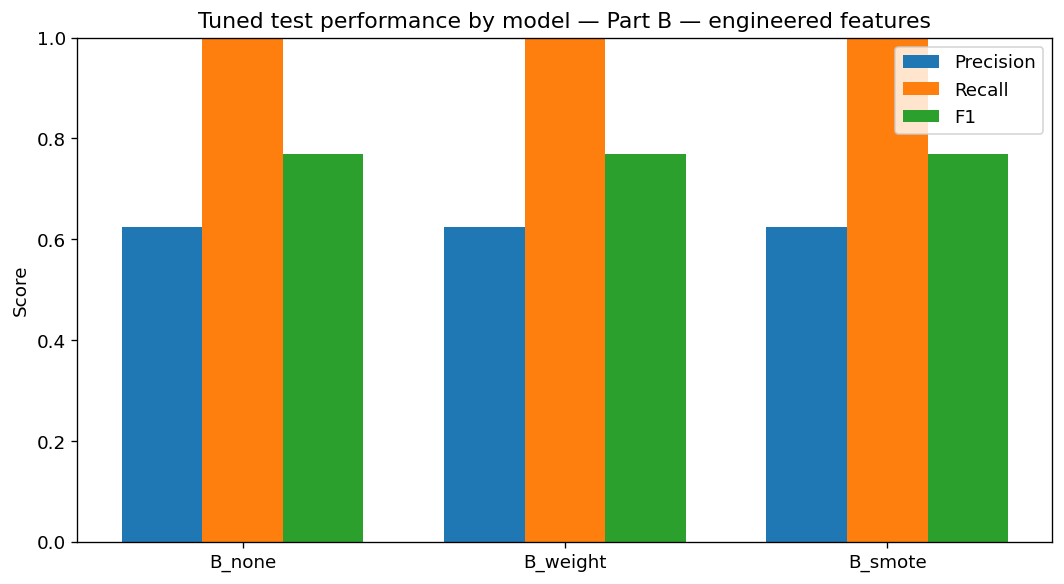

In [81]:
import numpy as np
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_b["model"])); width = 0.25
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_b[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_b["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model — Part B — engineered features")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison 

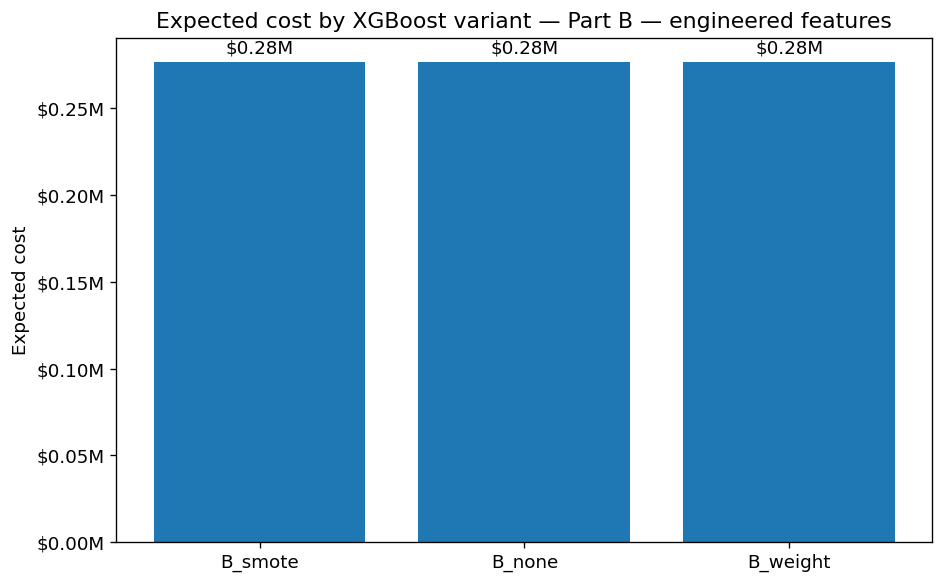

In [82]:
from matplotlib.ticker import FuncFormatter
cost_plot_df = comparison_b.sort_values("tuned_expected_cost")
plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by XGBoost variant — Part B — engineered features")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout(); plt.show()


## Threshold performance plot — Part B — engineered features

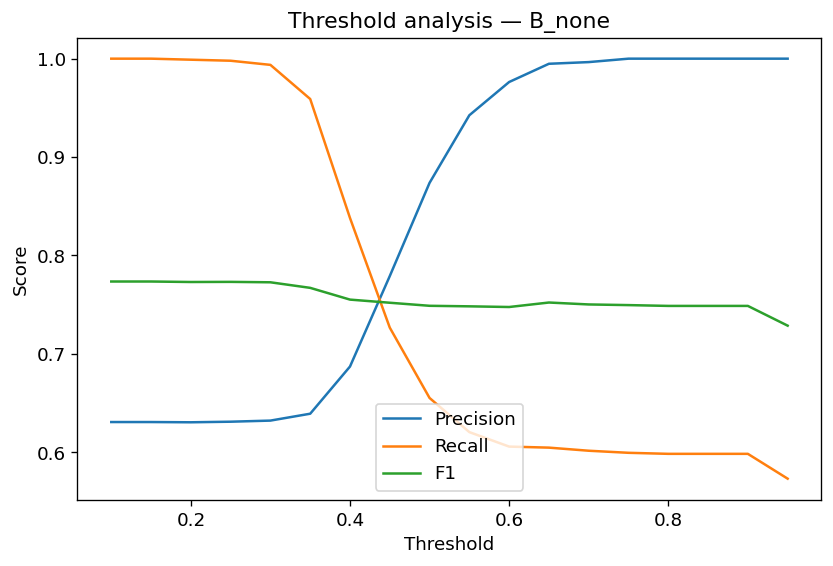

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["precision"], label="Precision")
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["recall"],    label="Recall")
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["f1"],        label="F1")
plt.title("Threshold analysis — B_none")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices 

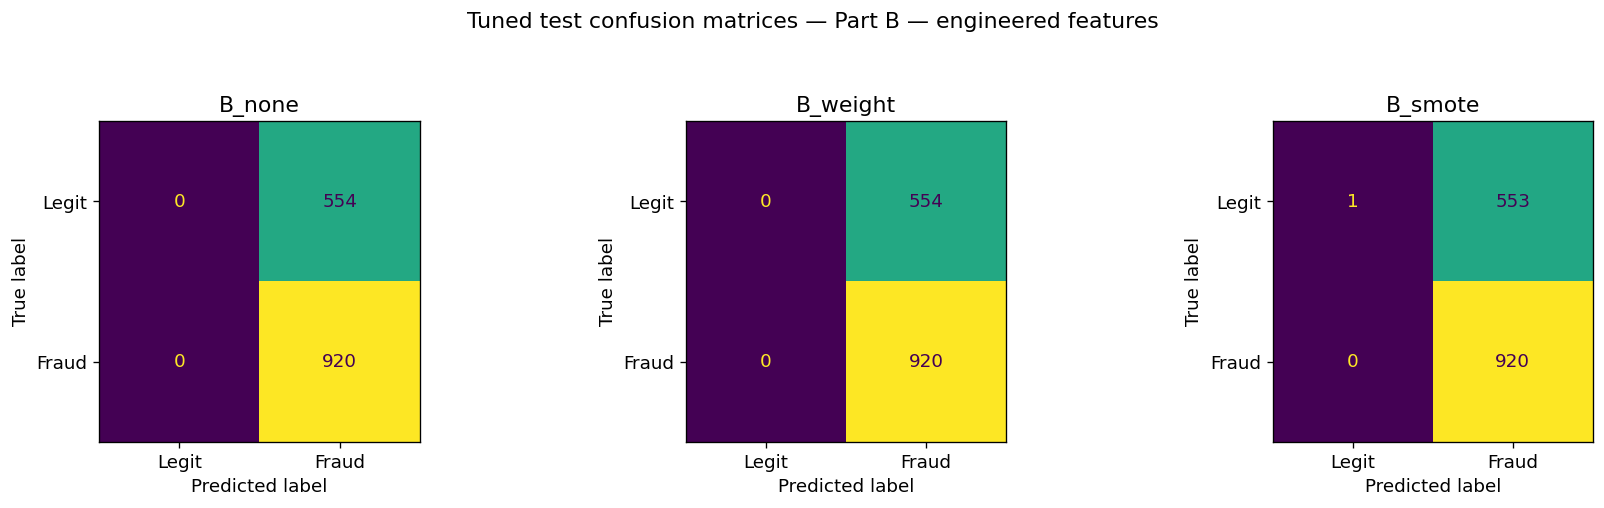

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_B_none, "B_none"), (tuned_cm_B_weight, "B_weight"), (tuned_cm_B_smote, "B_smote")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices — Part B — engineered features", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis 

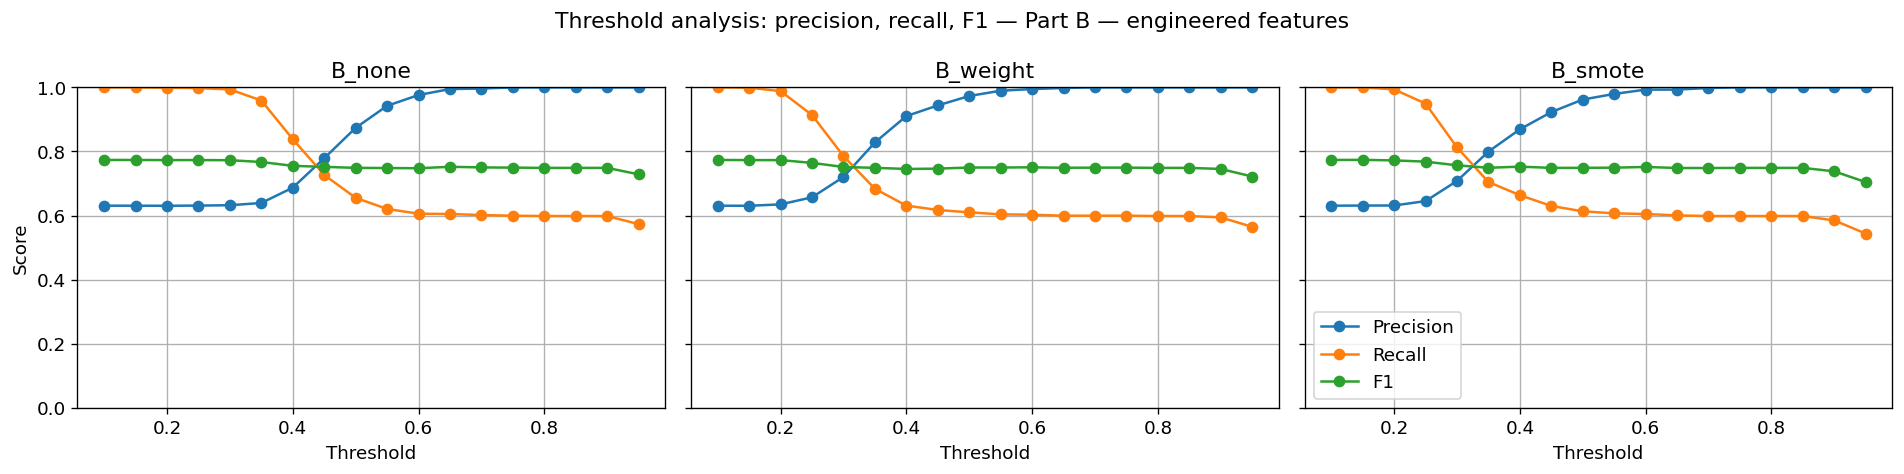

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_B_none, "B_none"), (threshold_results_B_weight, "B_weight"), (threshold_results_B_smote, "B_smote")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1 — Part B — engineered features")
plt.tight_layout(); plt.show()


## Expected cost by threshold 

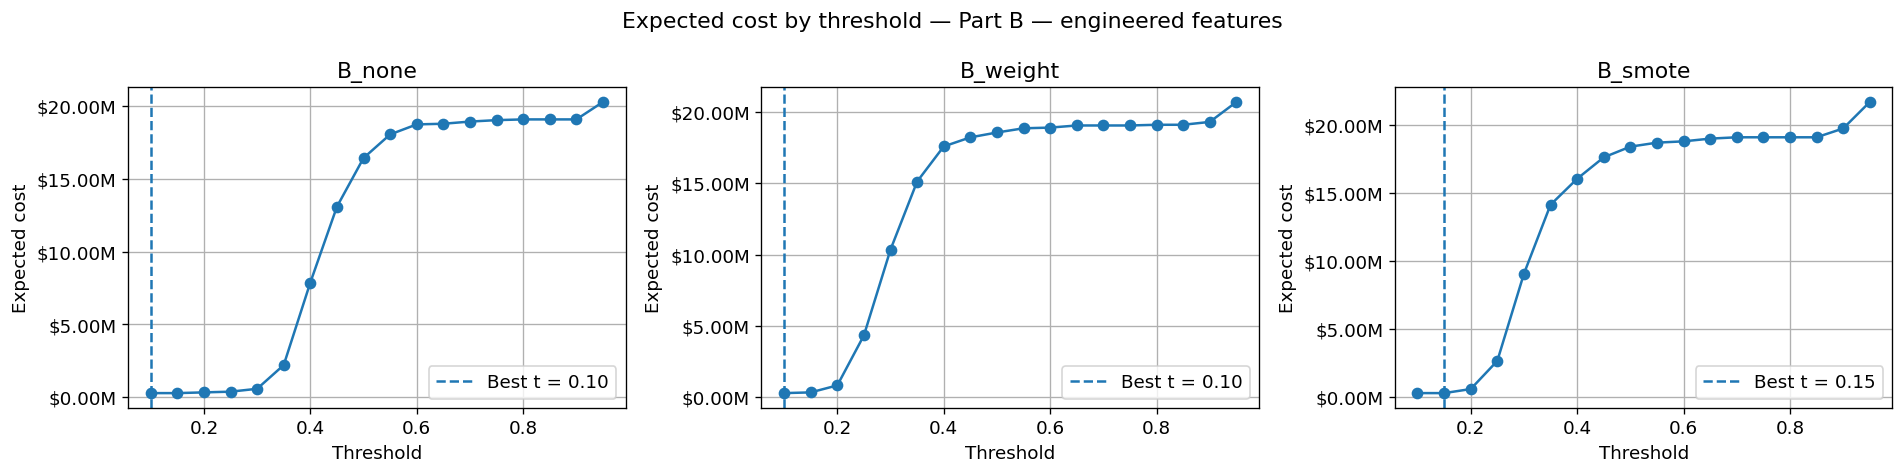

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_B_none, "B_none"), (cost_df_B_weight, "B_weight"), (cost_df_B_smote, "B_smote")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part B — engineered features")
plt.tight_layout(); plt.show()


## Precision-Recall curves 

In [87]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(X_val_fe, model_B_none.predict_proba(X_val_fe)[:, 1])
p_1, r_1, _ = precision_recall_curve(X_val_fe, model_B_weight.predict_proba(X_val_fe)[:, 1])
p_2, r_2, _ = precision_recall_curve(X_val_fe, model_B_smote.predict_proba(X_val_fe)[:, 1])
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, label="B_none")
plt.plot(r_1, p_1, label="B_weight")
plt.plot(r_2, p_2, label="B_smote")
plt.title("Precision-Recall curves — Part B — engineered features")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


ValueError: continuous-multioutput format is not supported

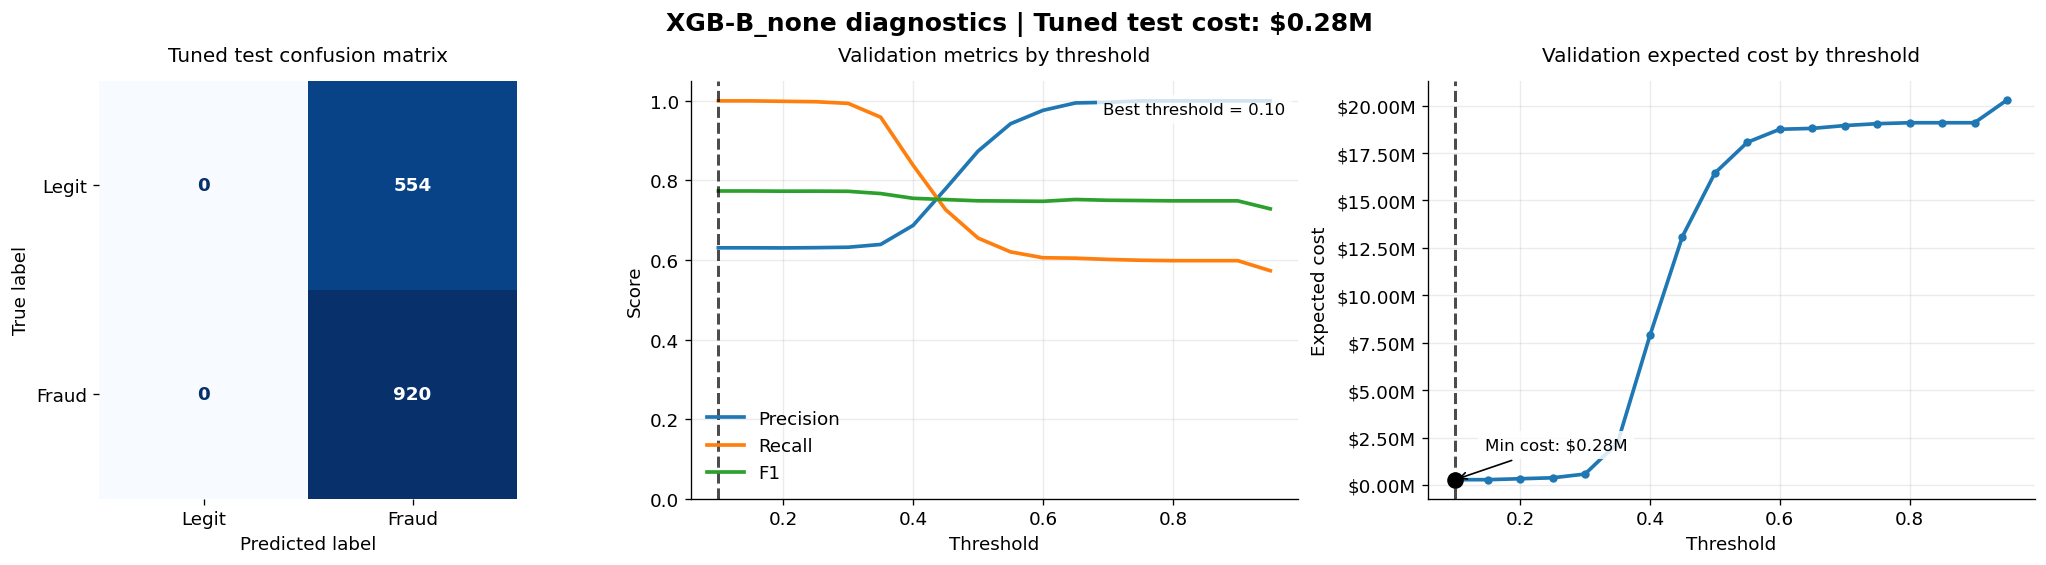

In [88]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_none,
    threshold_results=threshold_results_B_none,
    cost_df=cost_df_B_none,
    model_name="XGB-B_none",
    save_path=RESULTS_ROOT / "diagnostics_B_none.png",
)


XGB-B_none selects threshold 0.10 and predicts all test samples as fraud. This removes false negatives and gives a low expected cost of about $0.28M, but it also produces 554 false positives and zero true negatives. Engineered features improve the default-threshold result, but they do not prevent the cost-tuned model from collapsing into an all-fraud classifier.

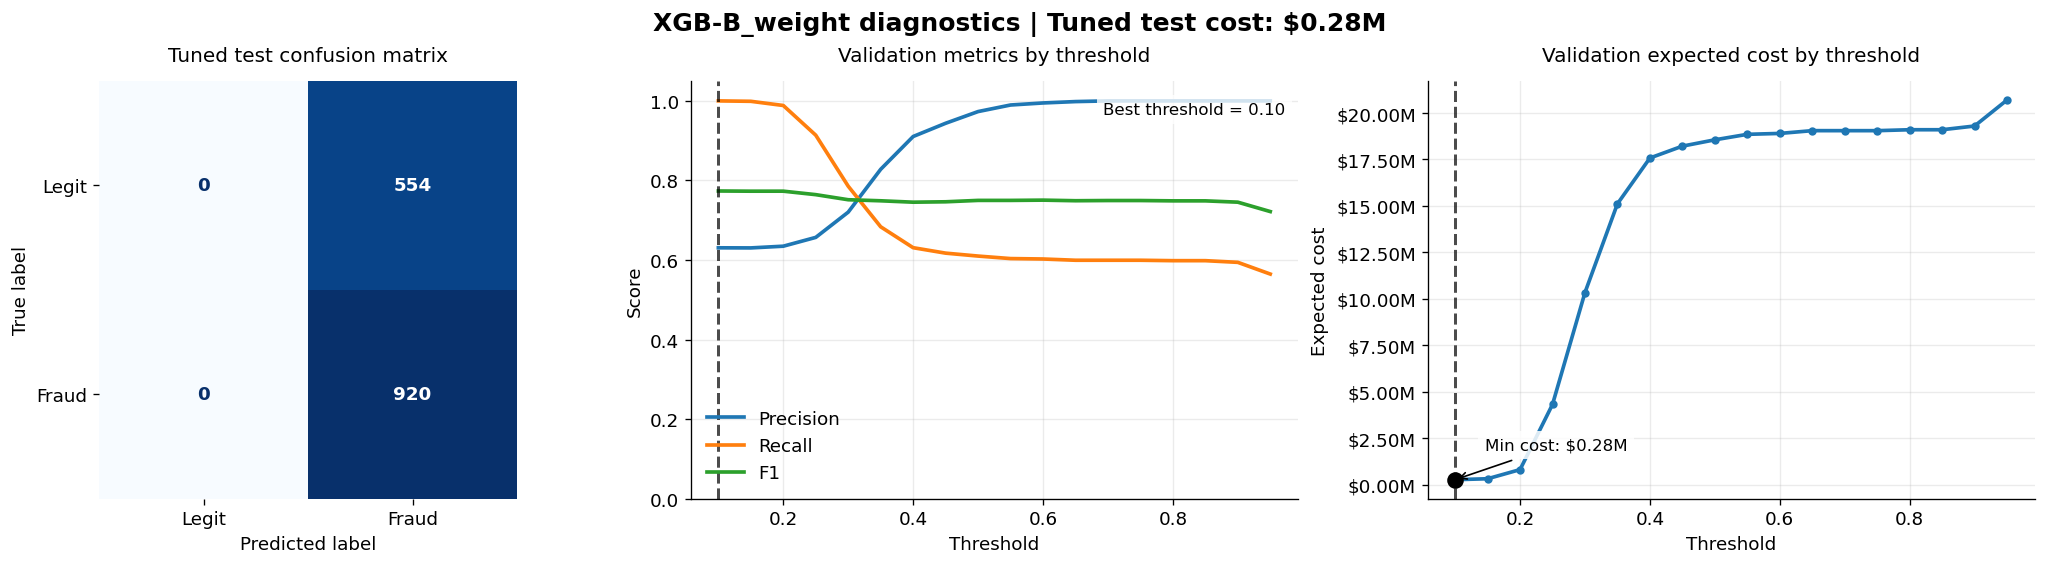

In [89]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_weight,
    threshold_results=threshold_results_B_weight,
    cost_df=cost_df_B_weight,
    model_name="XGB-B_weight",
    save_path=RESULTS_ROOT / "diagnostics_B_weight.png",
)


XGB-B_weight also selects threshold 0.10 and predicts all test samples as fraud. This gives zero false negatives and a low expected cost of about $0.28M, but it also produces 554 false positives and zero true negatives. Although the default-threshold model was conservative, cost-based tuning removes that behavior and turns it into an all-fraud classifier.

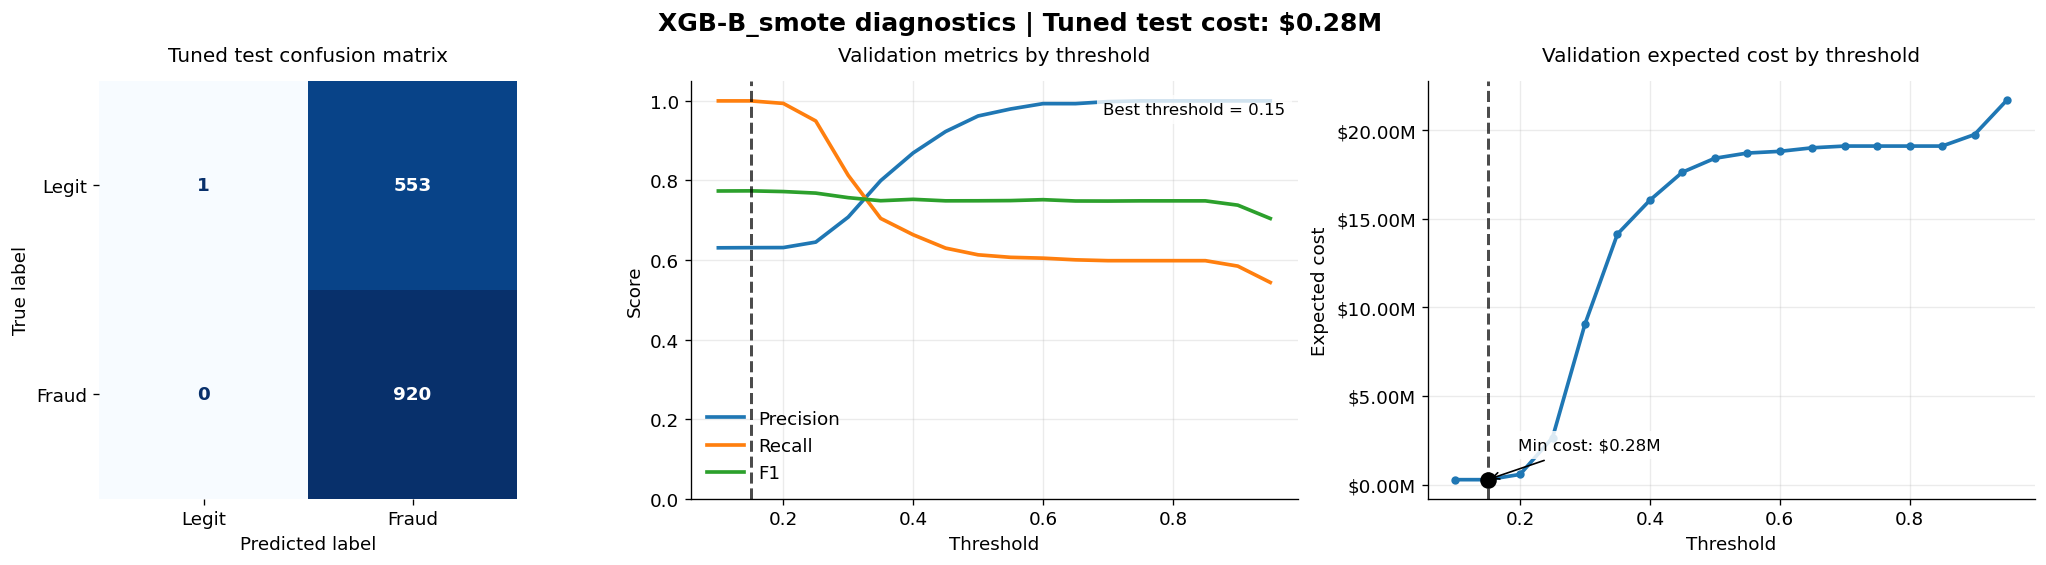

In [90]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_smote,
    threshold_results=threshold_results_B_smote,
    cost_df=cost_df_B_smote,
    model_name="XGB-B_smote",
    save_path=RESULTS_ROOT / "diagnostics_B_smote.png",
)


XGB-B_smote behaves almost the same as XGB-B_weigh after cost-based tuning. Both models detect all fraud cases but classify nearly all legitimate cases as fraud. This suggests that, once the threshold is tuned to minimize expected cost, the effect of SMOTE versus class weighting becomes very small.

## Final choice  Part B  engineered features

In [91]:
final_b = comparison_b.sort_values("tuned_expected_cost").copy()
final_b


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,B_smote,0.748876,0.789667,0.898248,0.753177,0.807684,0.904170,0.15,0.624576,1.0,0.768909,276500
0,B_none,0.748798,0.786112,0.897102,0.753149,0.802141,0.901974,0.10,0.624152,1.0,0.768588,277000
1,B_weight,0.749838,0.784460,0.896451,0.747651,0.799320,0.900616,0.10,0.624152,1.0,0.768588,277000


---
## Combined comparison - all six variants

In [92]:
all_variants = pd.concat([comparison_a, comparison_b], ignore_index=True)
all_variants = all_variants.sort_values("tuned_expected_cost").reset_index(drop=True)
all_variants[["model","best_threshold","tuned_test_precision",
              "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_smote,0.15,0.624576,1.0,0.768909,276500
1,A_none,0.10,0.624152,1.0,0.768588,277000
2,A_smote,0.10,0.624152,1.0,0.768588,277000
3,A_weight,0.10,0.624152,1.0,0.768588,277000
4,B_none,0.10,0.624152,1.0,0.768588,277000
5,B_weight,0.10,0.624152,1.0,0.768588,277000


In [93]:
all_variants.to_csv(RESULTS_ROOT / "comparison.csv", index=False)
print("Saved to:", RESULTS_ROOT / "comparison.csv")


Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\comparison.csv


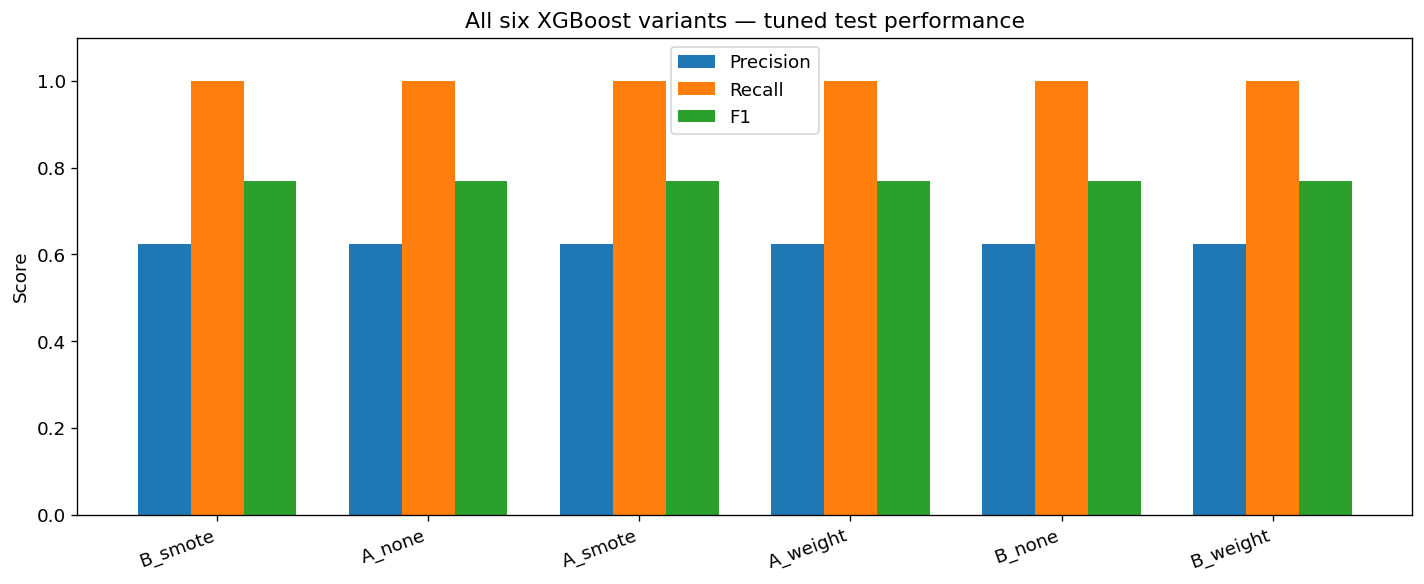

In [94]:
from matplotlib.ticker import FuncFormatter
x = np.arange(len(all_variants)); width = 0.25
plt.figure(figsize=(12, 5))
for i, (metric, lbl) in enumerate([("tuned_test_precision","Precision"),
                                    ("tuned_test_recall","Recall"),
                                    ("tuned_test_f1","F1")]):
    plt.bar(x + i*width, all_variants[metric], width, label=lbl)
plt.xticks(x + width, all_variants["model"], rotation=20, ha="right")
plt.ylabel("Score"); plt.title("All six XGBoost variants — tuned test performance")
plt.legend(); plt.ylim(0, 1.1); plt.tight_layout(); plt.show()


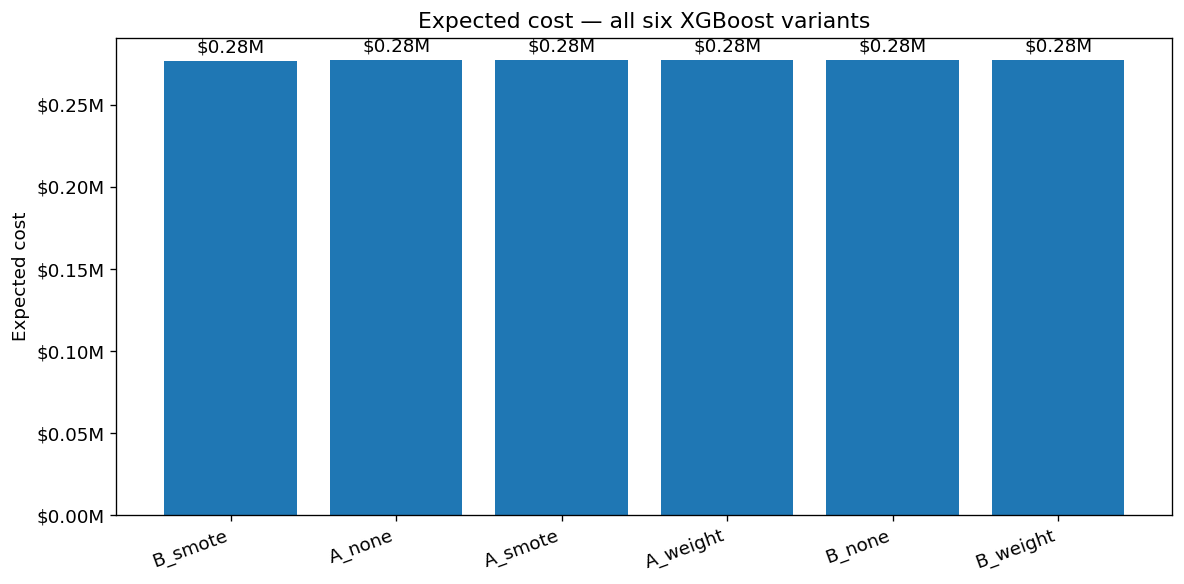

In [95]:
cost_all = all_variants.sort_values("tuned_expected_cost")
plt.figure(figsize=(10, 5))
bars = plt.bar(cost_all["model"], cost_all["tuned_expected_cost"])
plt.title("Expected cost — all six XGBoost variants")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_all["tuned_expected_cost"]],
    padding=3)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()


## Feature importance - best model

Best model: B_smote
                feature  importance
tab_orig_balance_zeroed    0.380955
 tab_balance_delta_orig    0.255652
             tab_type_4    0.073675
  tab_amount_ratio_orig    0.060787
             tab_type_1    0.042610
     tab_newbalanceOrig    0.027244
 tab_balance_delta_dest    0.024353
             tab_type_3    0.022692
             tab_amount    0.017691
  tab_amount_ratio_dest    0.016128
               tab_step    0.014760
     tab_newbalanceDest    0.014579
      tab_oldbalanceOrg    0.013649
             tab_type_2    0.013381
     tab_oldbalanceDest    0.011184
             tab_type_0    0.010660
     tab_isFlaggedFraud    0.000000


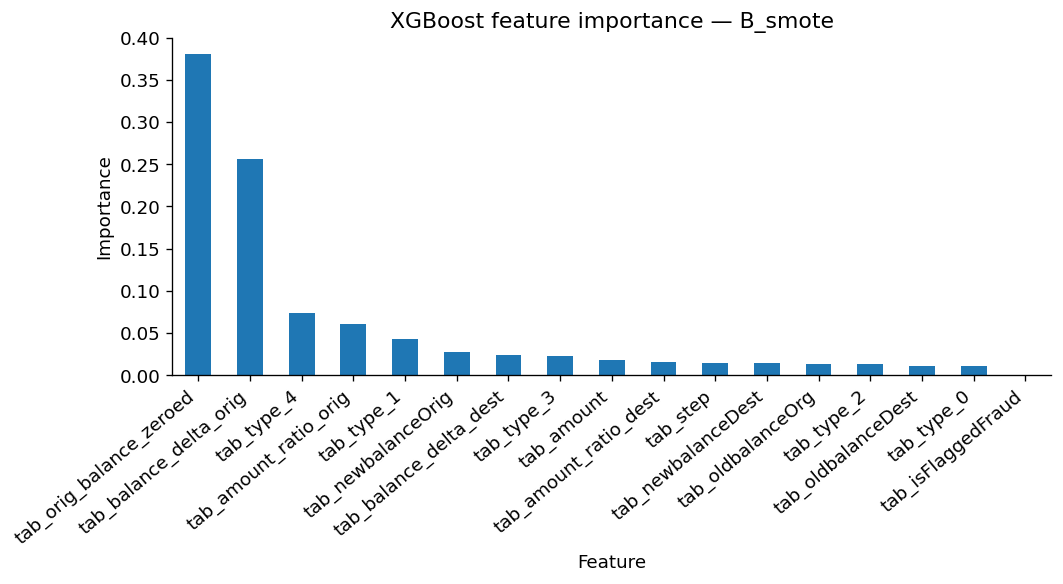

In [96]:
best_label = all_variants.iloc[0]["model"]
best_X_val = X_val_fe if best_label.startswith("B") else X_val_raw
feat_cols  = list(FE_COLS) if best_label.startswith("B") else list(RAW_COLS)
print(f"Best model: {best_label}")

model_lookup = {
    "A_none": model_A_none, "A_weight": model_A_weight, "A_smote": model_A_smote,
    "B_none": model_B_none, "B_weight": model_B_weight, "B_smote": model_B_smote,
}
best_model = model_lookup[best_label]

preprocessor_step = best_model.named_steps.get("preprocessor",
    best_model.named_steps.get("columntransformer", None))
xgb_step = list(best_model.named_steps.values())[-1]

try:
    feature_names = preprocessor_step.get_feature_names_out()
    feature_names = [f.split("__")[-1] for f in feature_names]
except Exception:
    feature_names = [f"f{i}" for i in range(len(xgb_step.feature_importances_))]

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_step.feature_importances_,
}).sort_values("importance", ascending=False)
print(feat_df.to_string(index=False))

ax = feat_df.plot(x="feature", y="importance", kind="bar",
                  figsize=(9, 5), legend=False)
ax.set_title(f"XGBoost feature importance — {best_label}")
ax.set_xlabel("Feature"); ax.set_ylabel("Importance")
ax.spines[["top","right"]].set_visible(False)
plt.xticks(rotation=40, ha="right"); plt.tight_layout()
plt.savefig(RESULTS_ROOT / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


The B_SMOTE feature-importance plot shows that XGBoost relies mainly on engineered balance features. The most important predictors are tab_orig_balance_zeroed and tab_balance_delta_orig, followed by transaction type and amount-ratio features. This confirms that engineered balance-discrepancy signals are useful for the tabular branch. However, despite improved feature representation, cost-based threshold tuning still produces an overly aggressive classifier on the multimodal subset.

## Final choice

In [97]:
final_choice_df = all_variants.sort_values("tuned_expected_cost").copy()
print("Best variant:", final_choice_df.iloc[0]["model"])
final_choice_df


Best variant: B_smote


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_smote,0.748876,0.789667,0.898248,0.753177,0.807684,0.904170,0.15,0.624576,1.0,0.768909,276500
1,A_none,0.746776,0.791150,0.897386,0.747266,0.795363,0.898535,0.10,0.624152,1.0,0.768588,277000
2,A_smote,0.744186,0.791322,0.897972,0.755671,0.801390,0.901592,0.10,0.624152,1.0,0.768588,277000
3,A_weight,0.746988,0.785793,0.895609,0.750494,0.798990,0.900992,0.10,0.624152,1.0,0.768588,277000
4,B_none,0.748798,0.786112,0.897102,0.753149,0.802141,0.901974,0.10,0.624152,1.0,0.768588,277000
5,B_weight,0.749838,0.784460,0.896451,0.747651,0.799320,0.900616,0.10,0.624152,1.0,0.768588,277000
